# Sprint 1

## Task 1.1: Project Setup and Data Exploration

#### Ticket 1.1.1: Set up GitHub repository with proper structure and documentation

##### 1- Create repository with README, .gitignore, and project directories (data/, notebooks/, src/)

##### 2- Document environment setup instructions

#### Ticket 1.1.2: Load and examine the dataset structure

##### 1- Import datasets and check dimensions, column types, and missing values

In [21]:
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

from sklearn.compose import ColumnTransformer
from sklearn.preprocessing import OneHotEncoder
from scipy import stats
import numpy as np
from matplotlib_venn import venn2
from scipy.stats import chi2_contingency
from sklearn.impute import SimpleImputer
import joblib

from sklearn.preprocessing import OrdinalEncoder, LabelEncoder

from sklearn.preprocessing import PolynomialFeatures
from sklearn.linear_model import LinearRegression


In [2]:
#df= pd.read_csv('../data/training_set_features.csv')

In [3]:
#train_data.head()

In [4]:
#open the datasets
submission = pd.read_csv("../data/submission_format.csv")
# print(submission)
test_features = pd.read_csv("../data/test_set_features.csv")
# print(test_features)
train_features = pd.read_csv("../data/training_set_features.csv")
# print(train_features)
train_labels = pd.read_csv("../data/training_set_labels.csv")
# print (train_labels)



In [5]:
#merge the X and Y training datasets 
train_data = train_features.merge(train_labels, on='respondent_id')
train_data.info()
train_data.head()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 26707 entries, 0 to 26706
Data columns (total 38 columns):
 #   Column                       Non-Null Count  Dtype  
---  ------                       --------------  -----  
 0   respondent_id                26707 non-null  int64  
 1   h1n1_concern                 26615 non-null  float64
 2   h1n1_knowledge               26591 non-null  float64
 3   behavioral_antiviral_meds    26636 non-null  float64
 4   behavioral_avoidance         26499 non-null  float64
 5   behavioral_face_mask         26688 non-null  float64
 6   behavioral_wash_hands        26665 non-null  float64
 7   behavioral_large_gatherings  26620 non-null  float64
 8   behavioral_outside_home      26625 non-null  float64
 9   behavioral_touch_face        26579 non-null  float64
 10  doctor_recc_h1n1             24547 non-null  float64
 11  doctor_recc_seasonal         24547 non-null  float64
 12  chronic_med_condition        25736 non-null  float64
 13  child_under_6_mo

,respondent_id,h1n1_concern,h1n1_knowledge,behavioral_antiviral_meds,behavioral_avoidance,behavioral_face_mask,behavioral_wash_hands,behavioral_large_gatherings,behavioral_outside_home,behavioral_touch_face,...,rent_or_own,employment_status,hhs_geo_region,census_msa,household_adults,household_children,employment_industry,employment_occupation,h1n1_vaccine,seasonal_vaccine
0,0,1.0,0.0,0.0,0.0,0.0,0.0,0.0,1.0,1.0,...,Own,Not in Labor Force,oxchjgsf,Non-MSA,0.0,0.0,NaN,NaN,0,0
1,1,3.0,2.0,0.0,1.0,0.0,1.0,0.0,1.0,1.0,...,Rent,Employed,bhuqouqj,"MSA, Not Principle City",0.0,0.0,pxcmvdjn,xgwztkwe,0,1
2,2,1.0,1.0,0.0,1.0,0.0,0.0,0.0,0.0,0.0,...,Own,Employed,qufhixun,"MSA, Not Principle City",2.0,0.0,rucpziij,xtkaffoo,0,0
3,3,1.0,1.0,0.0,1.0,0.0,1.0,1.0,0.0,0.0,...,Rent,Not in Labor Force,lrircsnp,"MSA, Principle City",0.0,0.0,NaN,NaN,0,1
4,4,2.0,1.0,0.0,1.0,0.0,1.0,1.0,0.0,1.0,...,Own,Employed,qufhixun,"MSA, Not Principle City",1.0,0.0,wxleyezf,emcorrxb,0,0


In [6]:
pd.set_option("display.max_columns", None) # desplay all the columns

In [7]:
print("Dataset dimensions:", train_data.shape) 
print("Column types:\n", train_data.dtypes)
print("Missing values:\n", train_data.isnull().sum())

Dataset dimensions: (26707, 38)
Column types:
 respondent_id                    int64
h1n1_concern                   float64
h1n1_knowledge                 float64
behavioral_antiviral_meds      float64
behavioral_avoidance           float64
behavioral_face_mask           float64
behavioral_wash_hands          float64
behavioral_large_gatherings    float64
behavioral_outside_home        float64
behavioral_touch_face          float64
doctor_recc_h1n1               float64
doctor_recc_seasonal           float64
chronic_med_condition          float64
child_under_6_months           float64
health_worker                  float64
health_insurance               float64
opinion_h1n1_vacc_effective    float64
opinion_h1n1_risk              float64
opinion_h1n1_sick_from_vacc    float64
opinion_seas_vacc_effective    float64
opinion_seas_risk              float64
opinion_seas_sick_from_vacc    float64
age_group                       object
education                       object
race             

##### 2- Create dataset profile summary

In [8]:
print("Numerical Features Summary:")
print(train_data.describe())
print("\nCategorical Features Summary:")
print(train_data.describe(include="object"))

Numerical Features Summary:
       respondent_id  h1n1_concern  h1n1_knowledge  behavioral_antiviral_meds  \
count   26707.000000  26615.000000    26591.000000               26636.000000   
mean    13353.000000      1.618486        1.262532                   0.048844   
std      7709.791156      0.910311        0.618149                   0.215545   
min         0.000000      0.000000        0.000000                   0.000000   
25%      6676.500000      1.000000        1.000000                   0.000000   
50%     13353.000000      2.000000        1.000000                   0.000000   
75%     20029.500000      2.000000        2.000000                   0.000000   
max     26706.000000      3.000000        2.000000                   1.000000   

       behavioral_avoidance  behavioral_face_mask  behavioral_wash_hands  \
count          26499.000000          26688.000000           26665.000000   
mean               0.725612              0.068982               0.825614   
std           

In [9]:
# Frequency count
for column in train_data.columns:
    print(f"Value counts for column {column}:")
    print(train_data[column].value_counts())
    print()

Value counts for column respondent_id:
respondent_id
26706    1
0        1
1        1
26690    1
26689    1
        ..
7        1
6        1
5        1
4        1
3        1
Name: count, Length: 26707, dtype: int64

Value counts for column h1n1_concern:
h1n1_concern
2.0    10575
1.0     8153
3.0     4591
0.0     3296
Name: count, dtype: int64

Value counts for column h1n1_knowledge:
h1n1_knowledge
1.0    14598
2.0     9487
0.0     2506
Name: count, dtype: int64

Value counts for column behavioral_antiviral_meds:
behavioral_antiviral_meds
0.0    25335
1.0     1301
Name: count, dtype: int64

Value counts for column behavioral_avoidance:
behavioral_avoidance
1.0    19228
0.0     7271
Name: count, dtype: int64

Value counts for column behavioral_face_mask:
behavioral_face_mask
0.0    24847
1.0     1841
Name: count, dtype: int64

Value counts for column behavioral_wash_hands:
behavioral_wash_hands
1.0    22015
0.0     4650
Name: count, dtype: int64

Value counts for column behavioral_large_

#### Ticket 1.1.3: Create summary statistics for all features

##### 1- Generate statistics for numerical and categorical features

##### 2- Check target variable distributions and class balance

In [10]:
# Check the distribution of the 'h1n1_vaccine' target variable
print("H1N1 Vaccine Distribution:")
print(train_data['h1n1_vaccine'].value_counts(normalize=True))

# Check the distribution of the 'seasonal_vaccine' target variable
print("\nSeasonal Vaccine Distribution:")
print(train_data['seasonal_vaccine'].value_counts(normalize=True))

H1N1 Vaccine Distribution:
h1n1_vaccine
0    0.787546
1    0.212454
Name: proportion, dtype: float64

Seasonal Vaccine Distribution:
seasonal_vaccine
0    0.534392
1    0.465608
Name: proportion, dtype: float64


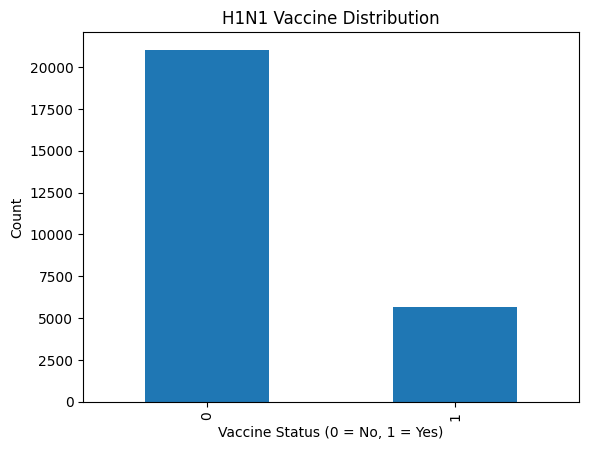

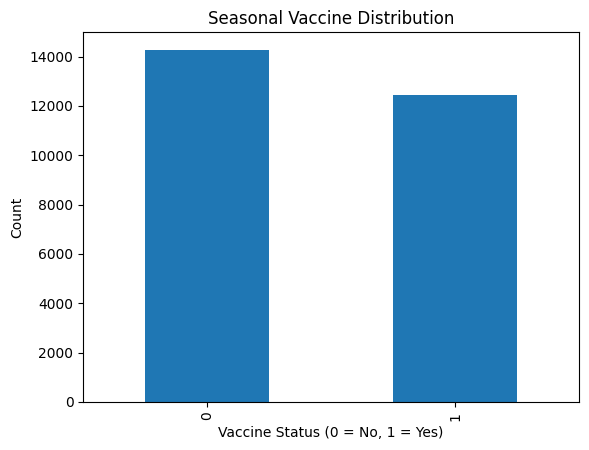

In [11]:
# Plot the distribution for 'h1n1_vaccine'
train_data['h1n1_vaccine'].value_counts().plot(kind='bar', title="H1N1 Vaccine Distribution")
plt.xlabel('Vaccine Status (0 = No, 1 = Yes)')
plt.ylabel('Count')
plt.show()

# Plot the distribution for 'seasonal_vaccine'
train_data['seasonal_vaccine'].value_counts().plot(kind='bar', title="Seasonal Vaccine Distribution")
plt.xlabel('Vaccine Status (0 = No, 1 = Yes)')
plt.ylabel('Count')
plt.show()

#### Ticket 1.1.4: Document initial observations and questions for further investigation

##### 1- Create markdown document with key observations


##### 2- List potential challenges and questions for deeper analysis

## Task 1.2: Data Cleaning and Preprocessing

#### Ticket 1.2.1: Handle missing values

##### 1- Analyze patterns of missingness and implement appropriate imputation strategies

In [12]:
# Calculate the percentage of missing values for each feature
missing_data = train_data.isnull().sum()
missing_percentage = (missing_data / len(train_data)) * 100

In [13]:
# Print the number of missing values and their percentage
print("Missing Values Count:")
print(missing_data)
print("\nMissing Values Percentage:")
print(missing_percentage)

Missing Values Count:
respondent_id                      0
h1n1_concern                      92
h1n1_knowledge                   116
behavioral_antiviral_meds         71
behavioral_avoidance             208
behavioral_face_mask              19
behavioral_wash_hands             42
behavioral_large_gatherings       87
behavioral_outside_home           82
behavioral_touch_face            128
doctor_recc_h1n1                2160
doctor_recc_seasonal            2160
chronic_med_condition            971
child_under_6_months             820
health_worker                    804
health_insurance               12274
opinion_h1n1_vacc_effective      391
opinion_h1n1_risk                388
opinion_h1n1_sick_from_vacc      395
opinion_seas_vacc_effective      462
opinion_seas_risk                514
opinion_seas_sick_from_vacc      537
age_group                          0
education                       1407
race                               0
sex                                0
income_poverty  

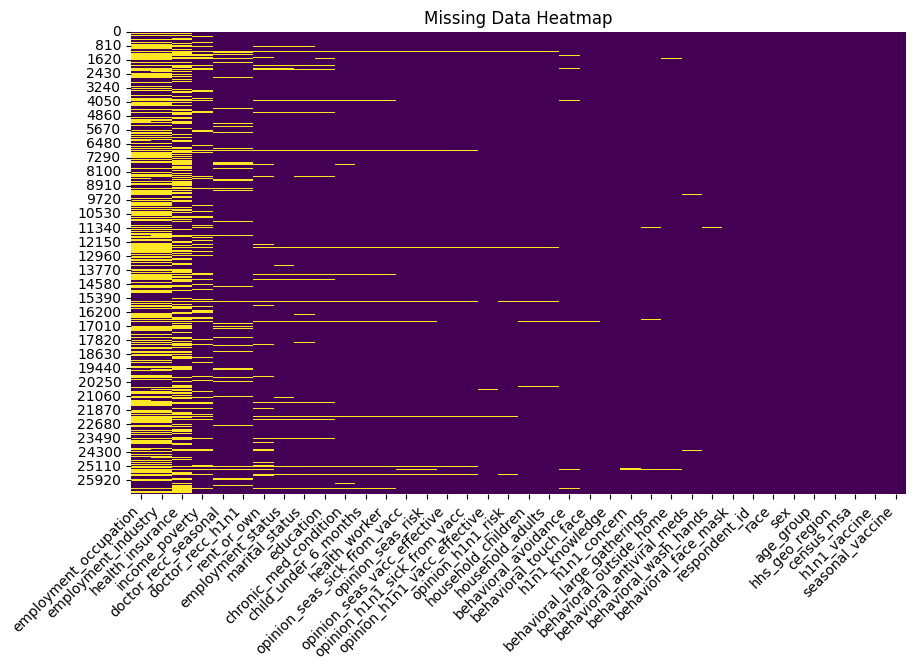

In [14]:
# Visualize missing data using a heatmap
plt.figure(figsize=(10, 6))
sns.heatmap(train_data.isnull(), cbar=False, cmap="viridis")
# Sort by missing count
sorted_cols = train_data.isnull().sum().sort_values(ascending=False).index
sns.heatmap(train_data[sorted_cols].isnull(), cbar=False, cmap="viridis")
plt.xticks(rotation=45, ha='right')


plt.title('Missing Data Heatmap')
plt.show()

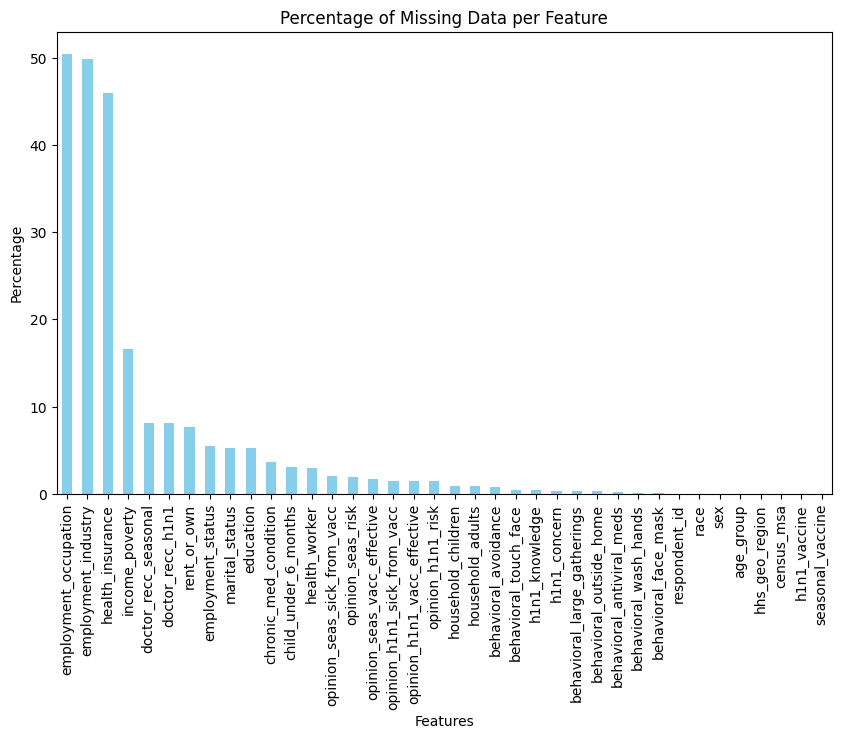

In [15]:
# Visualize the distribution of missing data per column
plt.figure(figsize=(10, 6))
missing_percentage.sort_values(ascending=False).plot(kind='bar', color='skyblue')
plt.title('Percentage of Missing Data per Feature')
plt.ylabel('Percentage')
plt.xlabel('Features')
plt.show()

In [16]:
# === Impute Numerical Columns ===
numerical_cols = ['household_adults', 'household_children']
for col in numerical_cols:
    if train_data[col].isnull().sum() > 0:
        mean_val = train_data[col].mean()
        train_data[col] = train_data[col].fillna(mean_val)
        print(f"[Imputation - Numeric] {col}: filled with mean = {mean_val:.2f}")

# === Impute Doctor Recommendation Columns (special constant fill) ===
doctor_rec_cols = ['doctor_recc_h1n1', 'doctor_recc_seasonal']
for col in doctor_rec_cols:
    if train_data[col].isnull().sum() > 0:
        train_data[col] = train_data[col].fillna(9999)
        print(f"[Imputation - Doctor] {col}: filled with constant 9999")

# === Impute Binary Columns (excluding doctor columns) ===
binary_cols = [
    'behavioral_antiviral_meds', 'behavioral_avoidance', 'behavioral_face_mask', 'behavioral_wash_hands',
    'behavioral_large_gatherings', 'behavioral_outside_home', 'behavioral_touch_face',
    'chronic_med_condition', 'child_under_6_months', 'health_worker', 'health_insurance'
]
for col in binary_cols:
    if train_data[col].isnull().sum() > 0:
        mode_val = train_data[col].mode()[0]
        train_data[col] = train_data[col].fillna(mode_val)
        print(f"[Imputation - Binary] {col}: filled with mode = {mode_val}")

# === Impute Employment Info Columns (use constant 'Not Applicable') ===
employment_info_cols = ['employment_industry', 'employment_occupation']
for col in employment_info_cols:
    if train_data[col].isnull().sum() > 0:
        train_data[col] = train_data[col].fillna('Not Applicable')
        print(f"[Imputation - Employment] {col}: filled with 'Not Applicable'")

# === Impute Other Categorical Columns (mode) ===
categorical_cols = [
    'age_group', 'education', 'race', 'sex', 'income_poverty', 'marital_status',
    'rent_or_own', 'employment_status', 'hhs_geo_region', 'census_msa'
]
for col in categorical_cols:
    if train_data[col].isnull().sum() > 0:
        mode_val = train_data[col].mode()[0]
        train_data[col] = train_data[col].fillna(mode_val)
        print(f"[Imputation - Categorical] {col}: filled with mode = '{mode_val}'")

# === Impute Ordinal Opinion Columns ===
ordinal_opinion_cols = [
    'h1n1_concern', 'h1n1_knowledge',
    'opinion_h1n1_vacc_effective', 'opinion_h1n1_risk', 'opinion_h1n1_sick_from_vacc',
    'opinion_seas_vacc_effective', 'opinion_seas_risk', 'opinion_seas_sick_from_vacc'
]

for col in ordinal_opinion_cols:
    if train_data[col].isnull().sum() > 0:
        mode_val = train_data[col].mode()[0]
        train_data[col] = train_data[col].fillna(mode_val)
        print(f"[Imputation - Ordinal Opinion] {col}: filled with mode = {mode_val}")




[Imputation - Numeric] household_adults: filled with mean = 0.89
[Imputation - Numeric] household_children: filled with mean = 0.53
[Imputation - Doctor] doctor_recc_h1n1: filled with constant 9999
[Imputation - Doctor] doctor_recc_seasonal: filled with constant 9999
[Imputation - Binary] behavioral_antiviral_meds: filled with mode = 0.0
[Imputation - Binary] behavioral_avoidance: filled with mode = 1.0
[Imputation - Binary] behavioral_face_mask: filled with mode = 0.0
[Imputation - Binary] behavioral_wash_hands: filled with mode = 1.0
[Imputation - Binary] behavioral_large_gatherings: filled with mode = 0.0
[Imputation - Binary] behavioral_outside_home: filled with mode = 0.0
[Imputation - Binary] behavioral_touch_face: filled with mode = 1.0
[Imputation - Binary] chronic_med_condition: filled with mode = 0.0
[Imputation - Binary] child_under_6_months: filled with mode = 0.0
[Imputation - Binary] health_worker: filled with mode = 0.0
[Imputation - Binary] health_insurance: filled with

##### 2- Document rationale for each imputation decision

#Document rationale for each imputation decision

- **Numerical columns**: Imputed using Mean. Assumes data is roughly normally distributed 
- **Categorical columns**: Imputed using mode (most frequent value), assuming missing entries reflect the most typical response.
- **Binary columns**: Mode. Preserves the most common binary outcome (e.g., 0 or 1).
- **Categorical Columns**: Mode
- **Ordinal Categorical**: Mode
- **Doctor Recommendation Columns**: Constant (fill_value=9999). Uses a placeholder to denote missing explicitly 
- **Employment Info**: Constant (fill_value='Not Applicable'). Indicates absence of employment info without losing category structure.


**Checking if there is a non-linear relationship between the variables**

h1n1_concern vaccination rates:
h1n1_concern
0.0    0.135619
1.0    0.171348
2.0    0.233336
3.0    0.292093
Name: h1n1_vaccine, dtype: float64



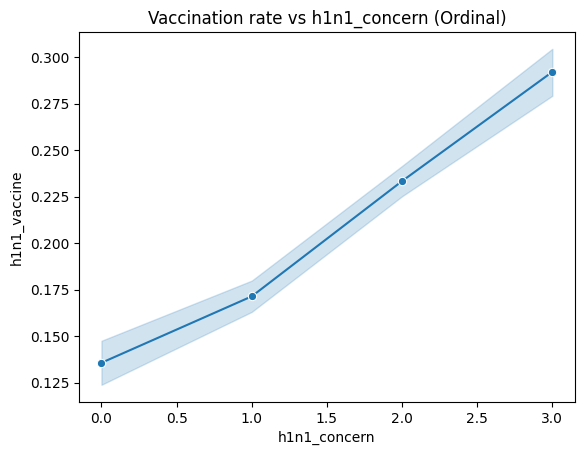

Spearman correlation between h1n1_concern and h1n1_vaccine: 0.122, p-value=1.68e-89
h1n1_knowledge vaccination rates:
h1n1_knowledge
0.0    0.144054
1.0    0.181800
2.0    0.278065
Name: h1n1_vaccine, dtype: float64



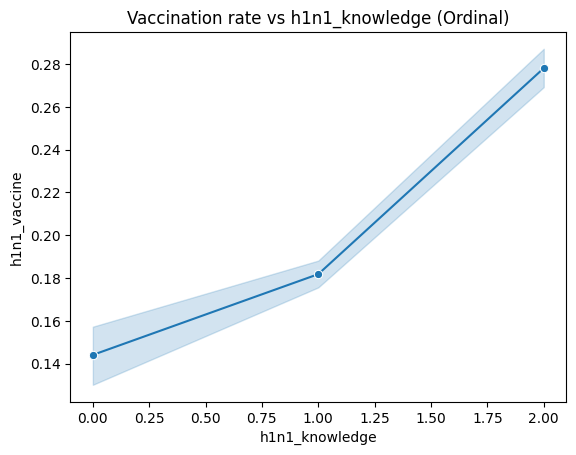

Spearman correlation between h1n1_knowledge and h1n1_vaccine: 0.121, p-value=5.19e-87
opinion_h1n1_vacc_effective vaccination rates:
opinion_h1n1_vacc_effective
1.0    0.047404
2.0    0.051130
3.0    0.105653
4.0    0.176992
5.0    0.404828
Name: h1n1_vaccine, dtype: float64



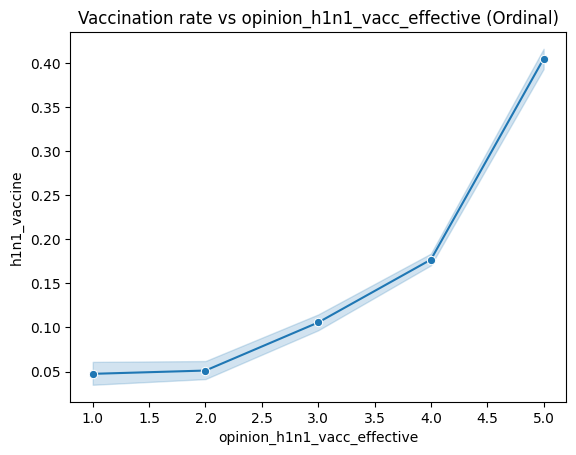

Spearman correlation between opinion_h1n1_vacc_effective and h1n1_vaccine: 0.290, p-value=0
opinion_h1n1_risk vaccination rates:
opinion_h1n1_risk
1.0    0.088340
2.0    0.169982
3.0    0.173679
4.0    0.392102
5.0    0.510857
Name: h1n1_vaccine, dtype: float64



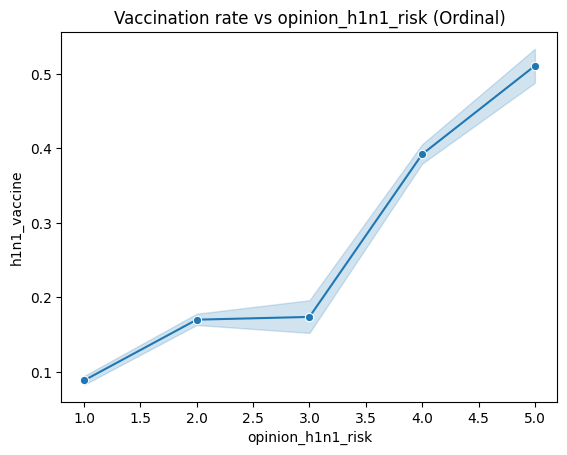

Spearman correlation between opinion_h1n1_risk and h1n1_vaccine: 0.303, p-value=0
opinion_h1n1_sick_from_vacc vaccination rates:
opinion_h1n1_sick_from_vacc
1.0    0.204601
2.0    0.174507
3.0    0.081081
4.0    0.264274
5.0    0.280293
Name: h1n1_vaccine, dtype: float64



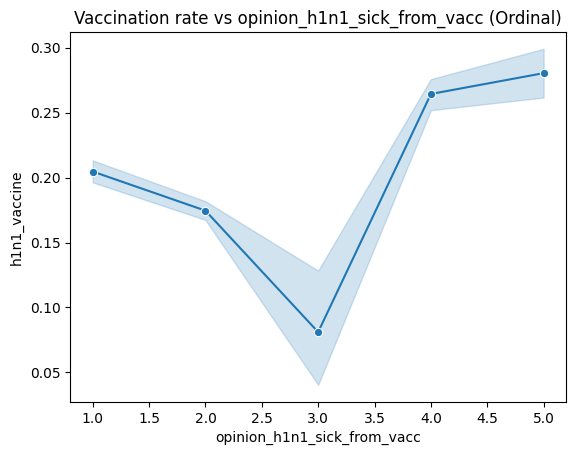

Spearman correlation between opinion_h1n1_sick_from_vacc and h1n1_vaccine: 0.059, p-value=9.67e-22
opinion_seas_vacc_effective vaccination rates:
opinion_seas_vacc_effective
1.0    0.072891
2.0    0.092928
3.0    0.133224
4.0    0.177157
5.0    0.308433
Name: h1n1_vaccine, dtype: float64



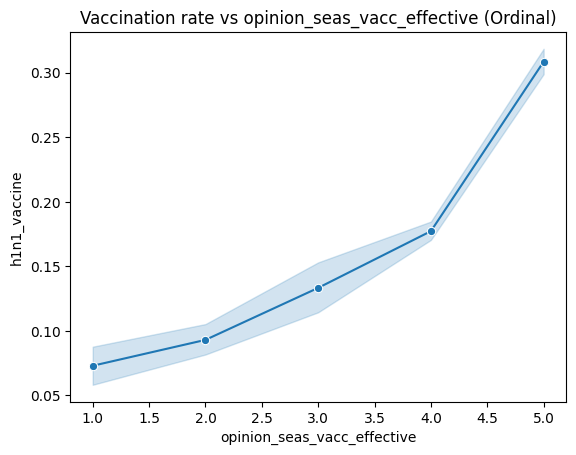

Spearman correlation between opinion_seas_vacc_effective and h1n1_vaccine: 0.194, p-value=2.05e-225
opinion_seas_risk vaccination rates:
opinion_seas_risk
1.0    0.084700
2.0    0.160013
3.0    0.200886
4.0    0.306029
5.0    0.399594
Name: h1n1_vaccine, dtype: float64



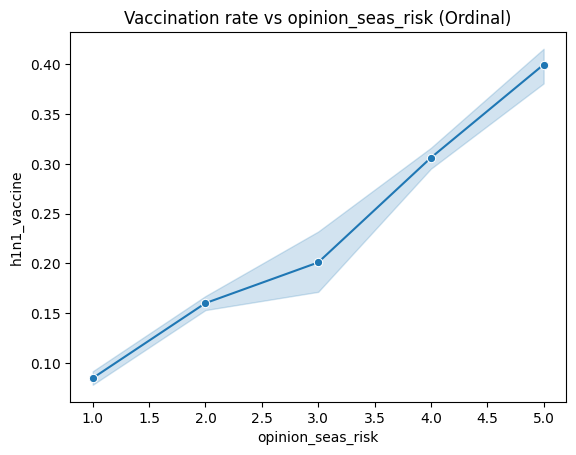

Spearman correlation between opinion_seas_risk and h1n1_vaccine: 0.254, p-value=0
opinion_seas_sick_from_vacc vaccination rates:
opinion_seas_sick_from_vacc
1.0    0.218909
2.0    0.189965
3.0    0.085106
4.0    0.229184
5.0    0.225450
Name: h1n1_vaccine, dtype: float64



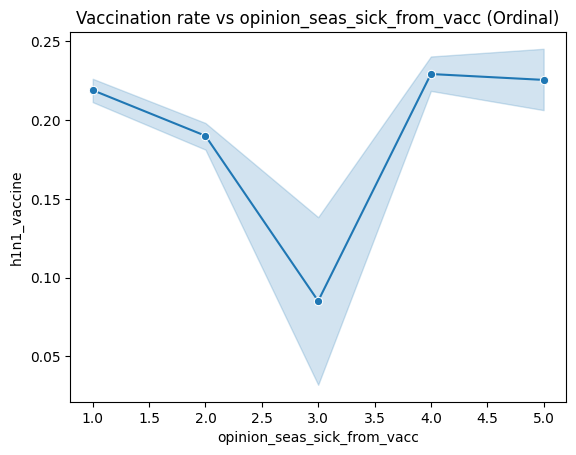

Spearman correlation between opinion_seas_sick_from_vacc and h1n1_vaccine: -0.002, p-value=0.804


In [17]:
for col in ordinal_opinion_cols:
    vacc_rate = train_data.groupby(col)['h1n1_vaccine'].mean()
    print(f"{col} vaccination rates:\n{vacc_rate}\n")

    sns.lineplot(x=col, y='h1n1_vaccine', data=train_data, marker='o')
    plt.title(f"Vaccination rate vs {col} (Ordinal)")
    plt.show()

    from scipy.stats import spearmanr
    corr, pval = spearmanr(train_data[col], train_data['h1n1_vaccine'])
    print(f"Spearman correlation between {col} and h1n1_vaccine: {corr:.3f}, p-value={pval:.3g}")



#### Ticket 1.2.2: Convert categorical variables to appropriate formats

##### 1- Apply encoding techniques (one-hot, label, ordinal) based on variable type

In [18]:
train_data.head()

,respondent_id,h1n1_concern,h1n1_knowledge,behavioral_antiviral_meds,behavioral_avoidance,behavioral_face_mask,behavioral_wash_hands,behavioral_large_gatherings,behavioral_outside_home,behavioral_touch_face,doctor_recc_h1n1,doctor_recc_seasonal,chronic_med_condition,child_under_6_months,health_worker,health_insurance,opinion_h1n1_vacc_effective,opinion_h1n1_risk,opinion_h1n1_sick_from_vacc,opinion_seas_vacc_effective,opinion_seas_risk,opinion_seas_sick_from_vacc,age_group,education,race,sex,income_poverty,marital_status,rent_or_own,employment_status,hhs_geo_region,census_msa,household_adults,household_children,employment_industry,employment_occupation,h1n1_vaccine,seasonal_vaccine
0,0,1.0,0.0,0.0,0.0,0.0,0.0,0.0,1.0,1.0,0.0,0.0,0.0,0.0,0.0,1.0,3.0,1.0,2.0,2.0,1.0,2.0,55 - 64 Years,< 12 Years,White,Female,Below Poverty,Not Married,Own,Not in Labor Force,oxchjgsf,Non-MSA,0.0,0.0,Not Applicable,Not Applicable,0,0
1,1,3.0,2.0,0.0,1.0,0.0,1.0,0.0,1.0,1.0,0.0,0.0,0.0,0.0,0.0,1.0,5.0,4.0,4.0,4.0,2.0,4.0,35 - 44 Years,12 Years,White,Male,Below Poverty,Not Married,Rent,Employed,bhuqouqj,"MSA, Not Principle City",0.0,0.0,pxcmvdjn,xgwztkwe,0,1
2,2,1.0,1.0,0.0,1.0,0.0,0.0,0.0,0.0,0.0,9999.0,9999.0,1.0,0.0,0.0,1.0,3.0,1.0,1.0,4.0,1.0,2.0,18 - 34 Years,College Graduate,White,Male,"<= $75,000, Above Poverty",Not Married,Own,Employed,qufhixun,"MSA, Not Principle City",2.0,0.0,rucpziij,xtkaffoo,0,0
3,3,1.0,1.0,0.0,1.0,0.0,1.0,1.0,0.0,0.0,0.0,1.0,1.0,0.0,0.0,1.0,3.0,3.0,5.0,5.0,4.0,1.0,65+ Years,12 Years,White,Female,Below Poverty,Not Married,Rent,Not in Labor Force,lrircsnp,"MSA, Principle City",0.0,0.0,Not Applicable,Not Applicable,0,1
4,4,2.0,1.0,0.0,1.0,0.0,1.0,1.0,0.0,1.0,0.0,0.0,0.0,0.0,0.0,1.0,3.0,3.0,2.0,3.0,1.0,4.0,45 - 54 Years,Some College,White,Female,"<= $75,000, Above Poverty",Married,Own,Employed,qufhixun,"MSA, Not Principle City",1.0,0.0,wxleyezf,emcorrxb,0,0


In [19]:

# Frequency count
for col in ['age_group', 'education', 'race', 'sex', 'income_poverty', 'marital_status', 'rent_or_own', 
            'employment_status', 'hhs_geo_region', 'census_msa', 'employment_industry', 'employment_occupation']:
    print(f"Value counts for {col}:")
    print(train_data[col].value_counts())
    print("-" * 30)


Value counts for age_group:
age_group
65+ Years        6843
55 - 64 Years    5563
45 - 54 Years    5238
18 - 34 Years    5215
35 - 44 Years    3848
Name: count, dtype: int64
------------------------------
Value counts for education:
education
College Graduate    11504
Some College         7043
12 Years             5797
< 12 Years           2363
Name: count, dtype: int64
------------------------------
Value counts for race:
race
White                21222
Black                 2118
Hispanic              1755
Other or Multiple     1612
Name: count, dtype: int64
------------------------------
Value counts for sex:
sex
Female    15858
Male      10849
Name: count, dtype: int64
------------------------------
Value counts for income_poverty:
income_poverty
<= $75,000, Above Poverty    17200
> $75,000                     6810
Below Poverty                 2697
Name: count, dtype: int64
------------------------------
Value counts for marital_status:
marital_status
Married        14963
Not Marri

In [22]:

# 1. Define the columns
ordinal_cols = ['age_group', 'education', 'income_poverty']
binary_cols = ['sex', 'marital_status', 'rent_or_own']
nominal_cols = ['race', 'hhs_geo_region', 'census_msa', 'employment_industry', 'employment_occupation', 'employment_status']

# 2. Define the category order for ordinal columns (same as pipeline)
age_order = ['18 - 34 Years', '35 - 44 Years', '45 - 54 Years', '55 - 64 Years', '65+ Years']
edu_order = ['< 12 Years', '12 Years', 'Some College', 'College Graduate']
income_order = ['Below Poverty', '<= $75,000, Above Poverty', '> $75,000']
enc_order = [age_order, edu_order, income_order]

# 3. Apply Ordinal Encoding (same settings)
ordinal_encoder = OrdinalEncoder(categories=enc_order, handle_unknown='use_encoded_value', unknown_value=-1)
train_data[ordinal_cols] = ordinal_encoder.fit_transform(train_data[ordinal_cols])

# 4. Apply Label Encoding for binary columns (multi-column version)
binary_encoders = {}
for col in binary_cols:
    le = LabelEncoder()
    train_data[col] = le.fit_transform(train_data[col])
    binary_encoders[col] = le  # Save for future use if needed

# 5. One-Hot Encoding for nominal columns (drop='first' to match pipeline)
train_data = pd.get_dummies(train_data, columns=nominal_cols, drop_first=True)

print("Encoding complete. Shape:", train_data.shape)


Encoding complete. Shape: (26707, 92)


##### 2- Implement appropriate treatment strategies and document impact

#Encoding summary

Ordinal Encoding:

Columns: age_group, education, income_poverty

Method: OrdinalEncoder with custom category order

Unknown values are handled by assigning -1.

Binary Encoding:

Columns: sex, marital_status, rent_or_own

Method: LabelEncoder applied individually per column

Converts categories into integers (e.g., "Male" → 1, "Female" → 0).

Nominal Encoding:

Columns: race, hhs_geo_region, census_msa, employment_industry, employment_occupation, employment_status

Method: pd.get_dummies(..., drop_first=True)

Performs one-hot encoding and drops the first level to avoid multicollinearity (dummy variable trap).

#### Ticket 1.2.3: Check for and handle outliers if necessary

Checking for Numerical Continuous variables


In [23]:

print(f"Summary before removing outliers for {col}:\n", train_data.describe())

Summary before removing outliers for rent_or_own:
        respondent_id  h1n1_concern  h1n1_knowledge  behavioral_antiviral_meds  \
count   26707.000000  26707.000000    26707.000000               26707.000000   
mean    13353.000000      1.619800        1.261392                   0.048714   
std      7709.791156      0.909016        0.617047                   0.215273   
min         0.000000      0.000000        0.000000                   0.000000   
25%      6676.500000      1.000000        1.000000                   0.000000   
50%     13353.000000      2.000000        1.000000                   0.000000   
75%     20029.500000      2.000000        2.000000                   0.000000   
max     26706.000000      3.000000        2.000000                   1.000000   

       behavioral_avoidance  behavioral_face_mask  behavioral_wash_hands  \
count          26707.000000          26707.000000           26707.000000   
mean               0.727749              0.068933               0.8

#### Ticket 1.2.4: Normalize/standardize numerical features if appropriate

##### 1- Apply scaling techniques based on data characteristics

##### 2- Create reusable scalers for test data

Summary for outliers analysis:
    We can apply outliers analysis only to continues numerical variables, and since the variables in the dataset are not continuous numerical, I guess we can skip this step. 

## Task 1.3: Exploratory Visualization

#### Ticket 1.3.1: Create visualizations for the distribution of target variables

##### 1- Generate charts showing H1N1 and seasonal vaccination rates

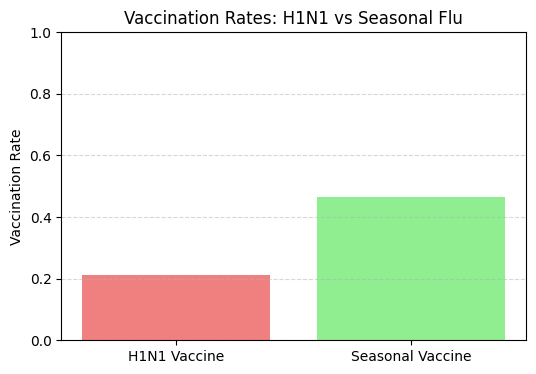

In [25]:
# Calculate vaccination rates (the proportion of people who got the vaccine)
h1n1_rate = train_data['h1n1_vaccine'].mean()
seasonal_rate = train_data['seasonal_vaccine'].mean()

# Plot
plt.figure(figsize=(6,4))
plt.bar(['H1N1 Vaccine', 'Seasonal Vaccine'], [h1n1_rate, seasonal_rate], color=['lightcoral', 'lightgreen'])
plt.ylim(0, 1)
plt.ylabel('Vaccination Rate')
plt.title('Vaccination Rates: H1N1 vs Seasonal Flu')
plt.grid(axis='y', linestyle='--', alpha=0.5)
plt.show()

##### 2- Visualize overlap between the two vaccination types

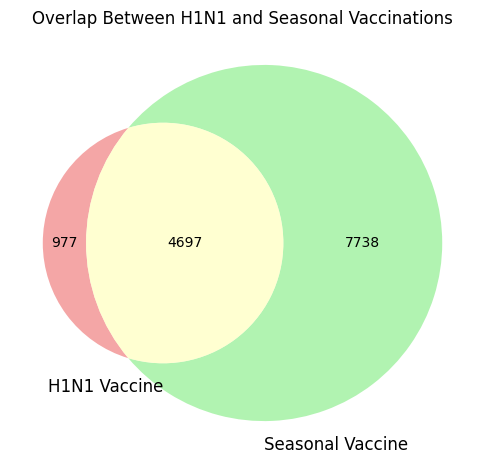

In [26]:
# Count each group
only_h1n1 = ((train_data['h1n1_vaccine'] == 1) & (train_data['seasonal_vaccine'] == 0)).sum()
only_seasonal = ((train_data['h1n1_vaccine'] == 0) & (train_data['seasonal_vaccine'] == 1)).sum()
both = ((train_data['h1n1_vaccine'] == 1) & (train_data['seasonal_vaccine'] == 1)).sum()

# Plot Venn
plt.figure(figsize=(6,6))
venn2(subsets=(only_h1n1, only_seasonal, both), 
      set_labels=('H1N1 Vaccine', 'Seasonal Vaccine'),
      set_colors=('lightcoral', 'lightgreen'), alpha=0.7)
plt.title("Overlap Between H1N1 and Seasonal Vaccinations")
plt.show()

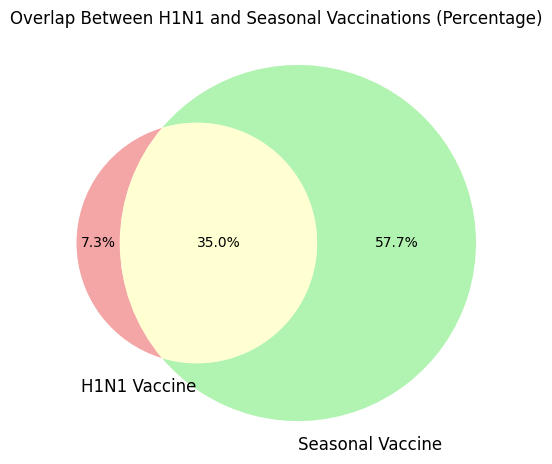

In [27]:
# Count each group
only_h1n1 = ((train_data['h1n1_vaccine'] == 1) & (train_data['seasonal_vaccine'] == 0)).sum()
only_seasonal = ((train_data['h1n1_vaccine'] == 0) & (train_data['seasonal_vaccine'] == 1)).sum()
both = ((train_data['h1n1_vaccine'] == 1) & (train_data['seasonal_vaccine'] == 1)).sum()

# Total number of relevant samples (only ones that took at least one vaccine)
total = only_h1n1 + only_seasonal + both

# Convert to percentages
only_h1n1_pct = only_h1n1 / total * 100
only_seasonal_pct = only_seasonal / total * 100
both_pct = both / total * 100

# Plot Venn with percentages
plt.figure(figsize=(6, 6))
venn = venn2(subsets=(only_h1n1_pct, only_seasonal_pct, both_pct), 
             set_labels=('H1N1 Vaccine', 'Seasonal Vaccine'),
             set_colors=('lightcoral', 'lightgreen'), alpha=0.7)

# Format the labels to show percentages
for idx in ['10', '01', '11']:  # '10' = only A, '01' = only B, '11' = both
    if venn.get_label_by_id(idx):
        label_value = float(venn.get_label_by_id(idx).get_text())
        venn.get_label_by_id(idx).set_text(f"{label_value:.1f}%")

plt.title("Overlap Between H1N1 and Seasonal Vaccinations (Percentage)")
plt.show()

#### Ticket 1.3.2: Visualize relationships between demographic variables and vaccination rates

##### 1- Create grouped bar charts and heatmaps by demographic variables

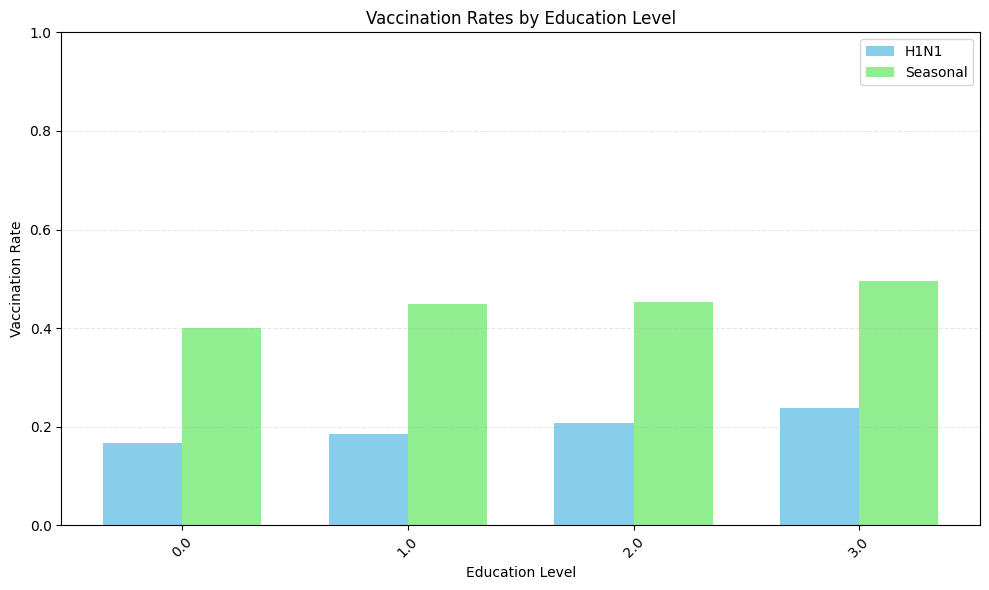

In [28]:

# Group by education and calculate mean vaccination rates
grouped_edu = train_data.groupby('education')[['h1n1_vaccine', 'seasonal_vaccine']].mean()

# Bar positions
x = np.arange(len(grouped_edu))
width = 0.35

# Plot
fig, ax = plt.subplots(figsize=(10, 6))
ax.bar(x - width/2, grouped_edu['h1n1_vaccine'], width, label='H1N1', color='skyblue')
ax.bar(x + width/2, grouped_edu['seasonal_vaccine'], width, label='Seasonal', color='lightgreen')

# Labels and formatting
ax.set_ylabel('Vaccination Rate')
ax.set_xlabel('Education Level')  #X-axis label
ax.set_title('Vaccination Rates by Education Level')
ax.set_xticks(x)
ax.set_xticklabels(grouped_edu.index, rotation=45)
ax.set_ylim(0, 1)
ax.legend()
plt.grid(axis='y', linestyle='--', alpha=0.3)
plt.tight_layout()
plt.show()

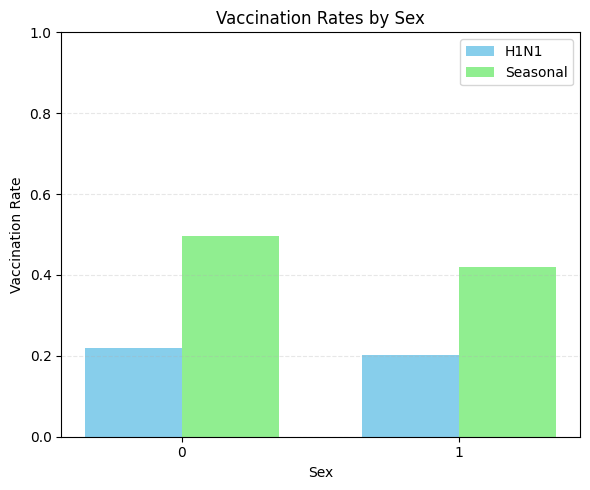

In [29]:
#Grouped bar charts for gender
grouped_sex = train_data.groupby('sex')[['h1n1_vaccine', 'seasonal_vaccine']].mean()
x = np.arange(len(grouped_sex))
width = 0.35

fig, ax = plt.subplots(figsize=(6, 5))
ax.bar(x - width/2, grouped_sex['h1n1_vaccine'], width, label='H1N1', color='skyblue')
ax.bar(x + width/2, grouped_sex['seasonal_vaccine'], width, label='Seasonal', color='lightgreen')

ax.set_ylabel('Vaccination Rate')
ax.set_xlabel('Sex')
ax.set_title('Vaccination Rates by Sex')
ax.set_xticks(x)
ax.set_xticklabels(grouped_sex.index)
ax.set_ylim(0, 1)
ax.legend()
plt.grid(axis='y', linestyle='--', alpha=0.3)
plt.tight_layout()
plt.show()


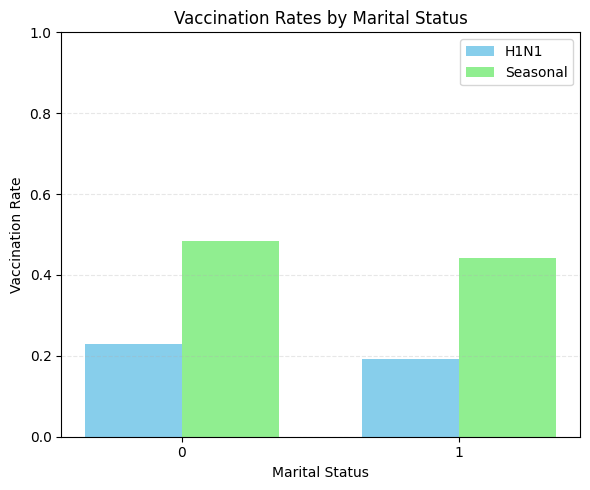

In [30]:
#Grouped bar charts for marital status

grouped_marital = train_data.groupby('marital_status')[['h1n1_vaccine', 'seasonal_vaccine']].mean()
x = np.arange(len(grouped_marital))

fig, ax = plt.subplots(figsize=(6, 5))
ax.bar(x - width/2, grouped_marital['h1n1_vaccine'], width, label='H1N1', color='skyblue')
ax.bar(x + width/2, grouped_marital['seasonal_vaccine'], width, label='Seasonal', color='lightgreen')

ax.set_ylabel('Vaccination Rate')
ax.set_xlabel('Marital Status')
ax.set_title('Vaccination Rates by Marital Status')
ax.set_xticks(x)
ax.set_xticklabels(grouped_marital.index)
ax.set_ylim(0, 1)
ax.legend()
plt.grid(axis='y', linestyle='--', alpha=0.3)
plt.tight_layout()
plt.show()

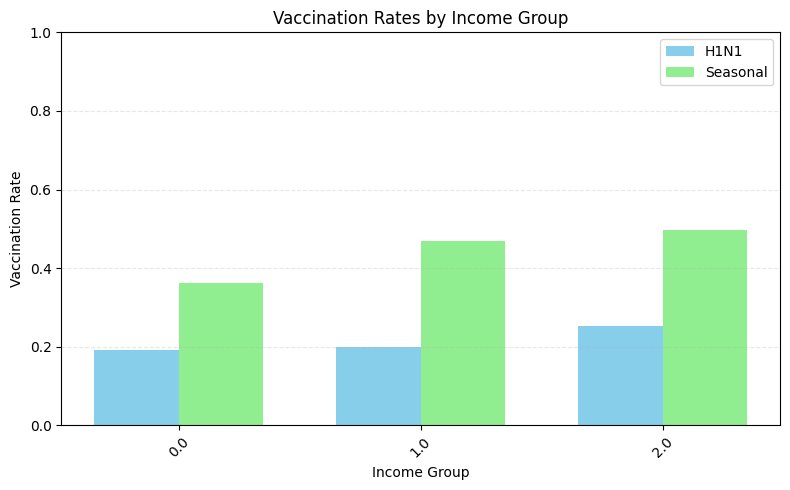

In [31]:
#Grouped bar charts for Income Group
grouped_income = train_data.groupby('income_poverty')[['h1n1_vaccine', 'seasonal_vaccine']].mean()
x = np.arange(len(grouped_income))

fig, ax = plt.subplots(figsize=(8, 5))
ax.bar(x - width/2, grouped_income['h1n1_vaccine'], width, label='H1N1', color='skyblue')
ax.bar(x + width/2, grouped_income['seasonal_vaccine'], width, label='Seasonal', color='lightgreen')

ax.set_ylabel('Vaccination Rate')
ax.set_xlabel('Income Group')
ax.set_title('Vaccination Rates by Income Group')
ax.set_xticks(x)
ax.set_xticklabels(grouped_income.index, rotation=45)
ax.set_ylim(0, 1)
ax.legend()
plt.grid(axis='y', linestyle='--', alpha=0.3)
plt.tight_layout()
plt.show()

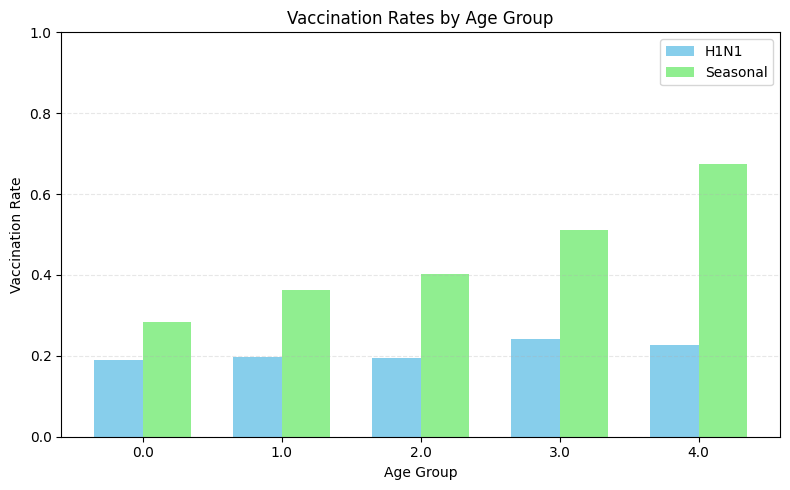

In [32]:
#Grouped bar charts for Age Group
grouped_age = train_data.groupby('age_group')[['h1n1_vaccine', 'seasonal_vaccine']].mean()
x = np.arange(len(grouped_age))

fig, ax = plt.subplots(figsize=(8, 5))
ax.bar(x - width/2, grouped_age['h1n1_vaccine'], width, label='H1N1', color='skyblue')
ax.bar(x + width/2, grouped_age['seasonal_vaccine'], width, label='Seasonal', color='lightgreen')

ax.set_ylabel('Vaccination Rate')
ax.set_xlabel('Age Group')
ax.set_title('Vaccination Rates by Age Group')
ax.set_xticks(x)
ax.set_xticklabels(grouped_age.index)
ax.set_ylim(0, 1)
ax.legend()
plt.grid(axis='y', linestyle='--', alpha=0.3)
plt.tight_layout()
plt.show()


In [33]:
#Grouped bar charts for Race
grouped_race = train_data.groupby('race')[['h1n1_vaccine', 'seasonal_vaccine']].mean()
x = np.arange(len(grouped_race))
width = 0.35

fig, ax = plt.subplots(figsize=(8, 5))
ax.bar(x - width/2, grouped_race['h1n1_vaccine'], width, label='H1N1', color='skyblue')
ax.bar(x + width/2, grouped_race['seasonal_vaccine'], width, label='Seasonal', color='lightgreen')

ax.set_ylabel('Vaccination Rate')
ax.set_xlabel('Race')
ax.set_title('Vaccination Rates by Race')
ax.set_xticks(x)
ax.set_xticklabels(grouped_race.index, rotation=15)
ax.set_ylim(0, 1)
ax.legend()
plt.grid(axis='y', linestyle='--', alpha=0.3)
plt.tight_layout()
plt.show()

KeyError: 'race'

In [34]:
#Grouped bar charts for Employment Status
grouped_emp = train_data.groupby('employment_status')[['h1n1_vaccine', 'seasonal_vaccine']].mean()
x = np.arange(len(grouped_emp))

fig, ax = plt.subplots(figsize=(7, 5))
ax.bar(x - width/2, grouped_emp['h1n1_vaccine'], width, label='H1N1', color='skyblue')
ax.bar(x + width/2, grouped_emp['seasonal_vaccine'], width, label='Seasonal', color='lightgreen')

ax.set_ylabel('Vaccination Rate')
ax.set_xlabel('Employment Status')
ax.set_title('Vaccination Rates by Employment Status')
ax.set_xticks(x)
ax.set_xticklabels(grouped_emp.index, rotation=15)
ax.set_ylim(0, 1)
ax.legend()
plt.grid(axis='y', linestyle='--', alpha=0.3)
plt.tight_layout()
plt.show()


KeyError: 'employment_status'

In [ ]:
import seaborn as sns
import matplotlib.pyplot as plt

def plot_heatmap(data, index_var, column_var, vaccine_col='h1n1_vaccine'):
    pivot = data.pivot_table(index=index_var, columns=column_var, values=vaccine_col, aggfunc='mean')
    
    plt.figure(figsize=(10, 6))
    sns.heatmap(pivot, annot=True, fmt=".2f", cmap='YlGnBu', cbar_kws={'label': f'{vaccine_col.replace("_", " ").title()} Rate'})
    plt.title(f'{vaccine_col.replace("_", " ").title()} Rate by {index_var.replace("_", " ").title()} and {column_var.replace("_", " ").title()}')
    plt.xlabel(column_var.replace('_', ' ').title())
    plt.ylabel(index_var.replace('_', ' ').title())
    plt.tight_layout()
    plt.show()


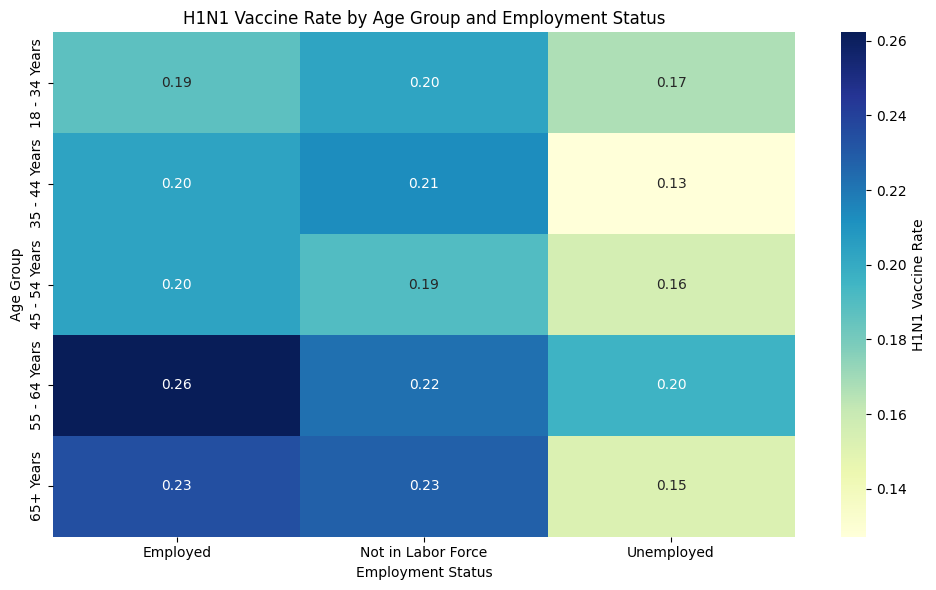

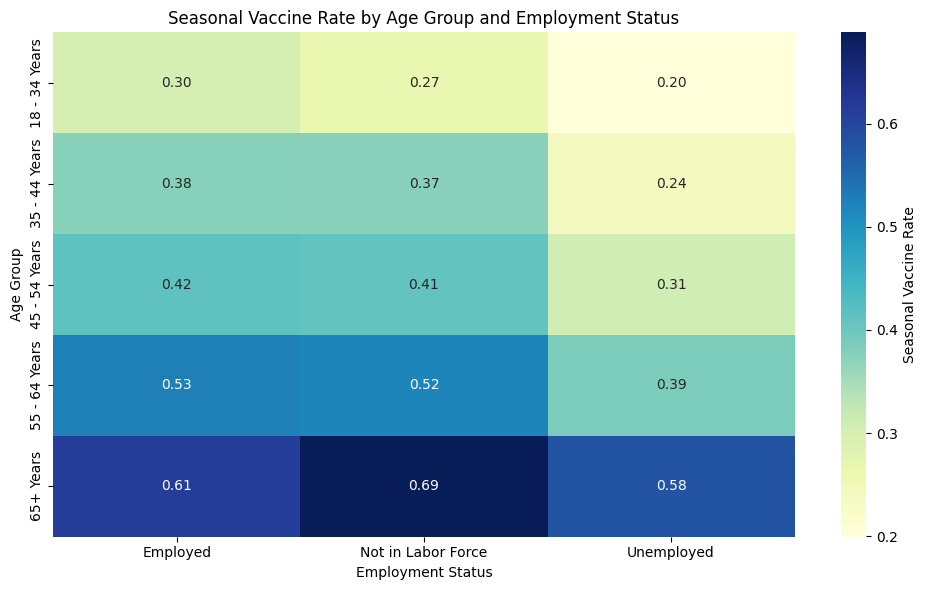

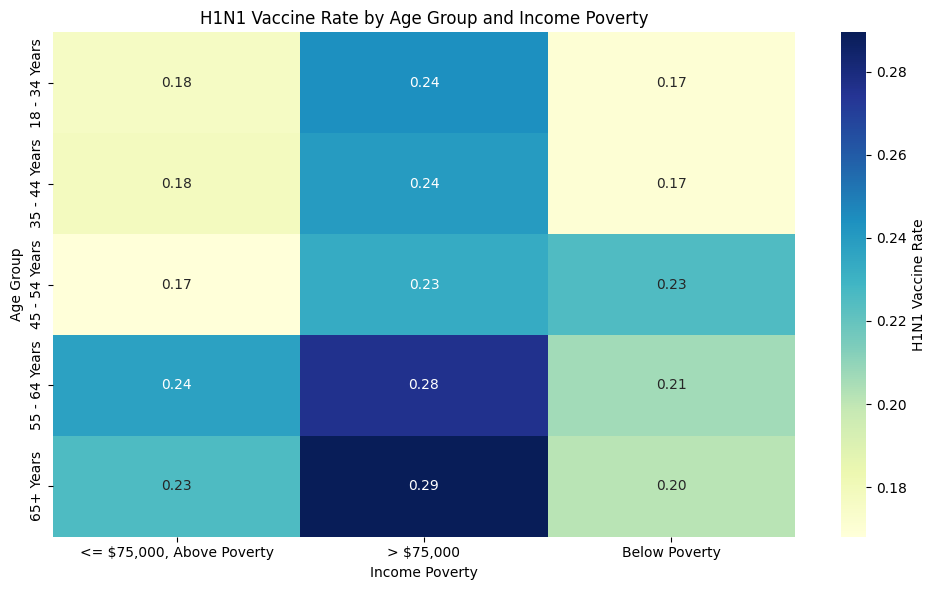

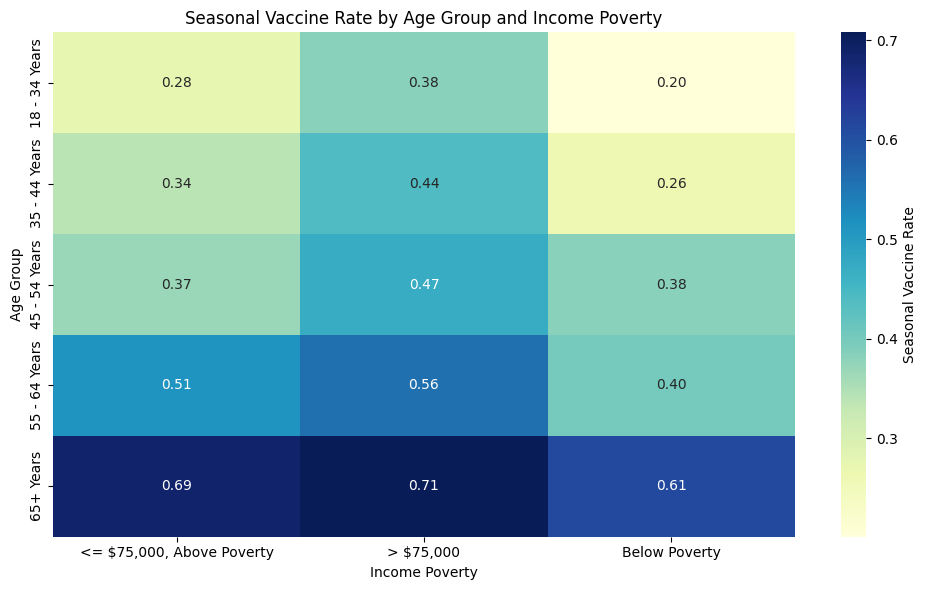

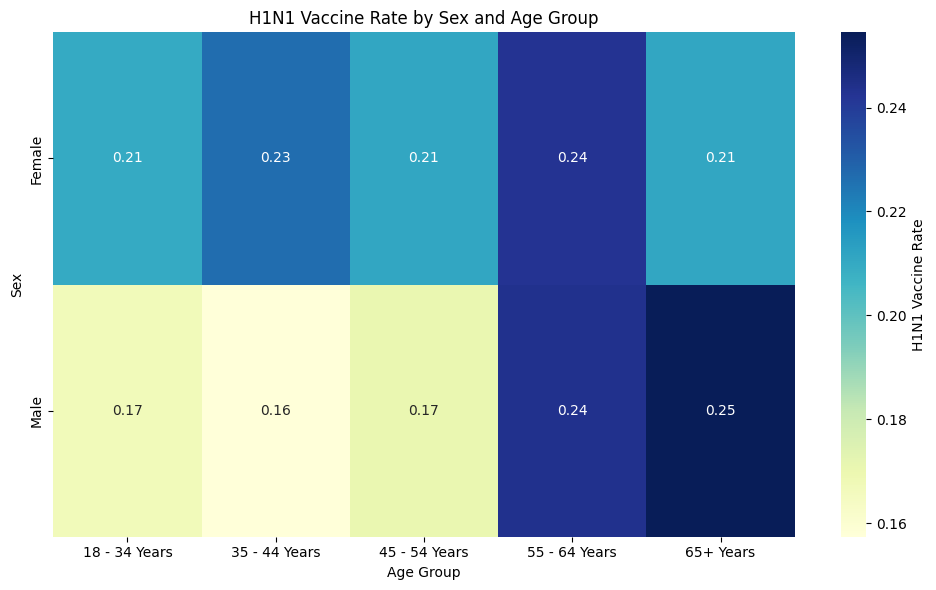

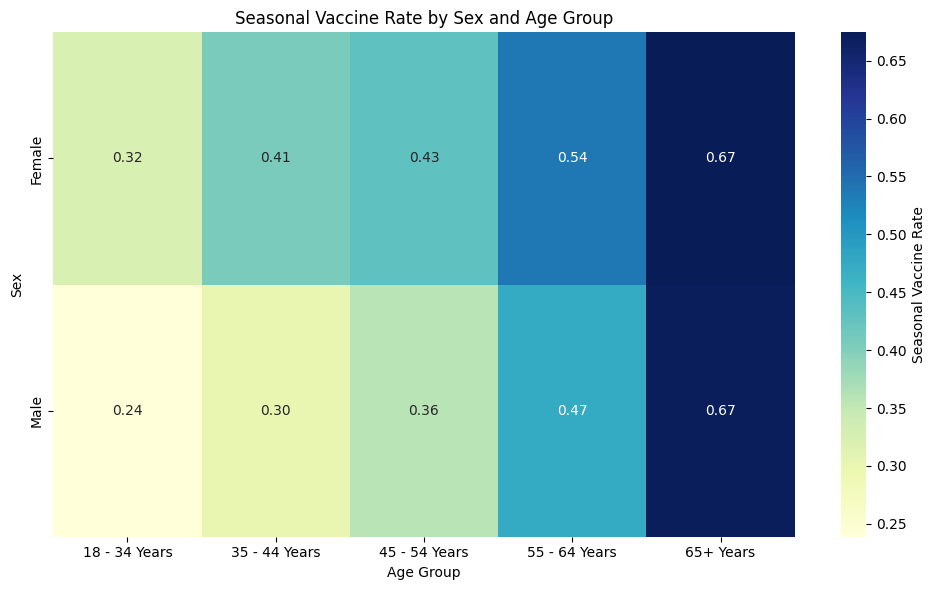

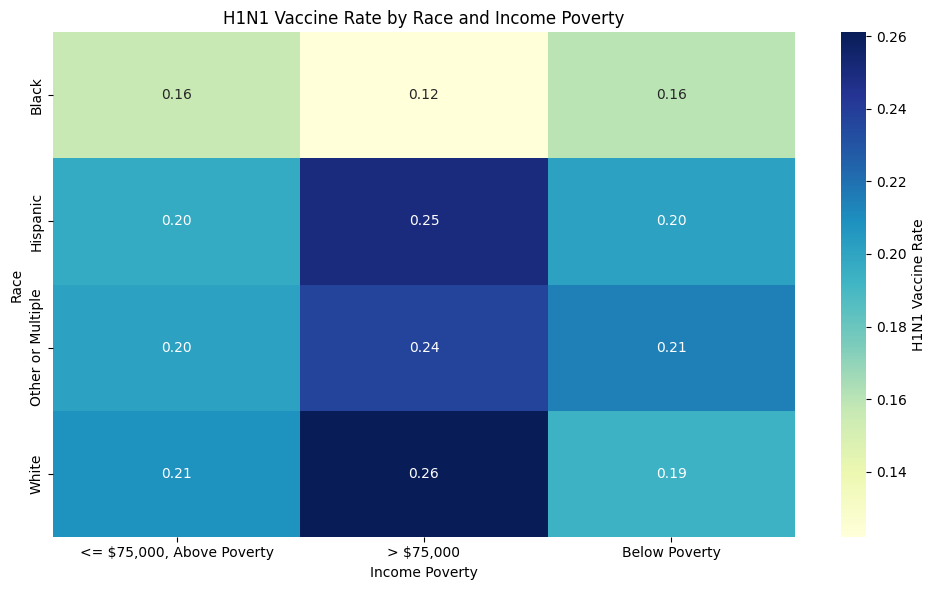

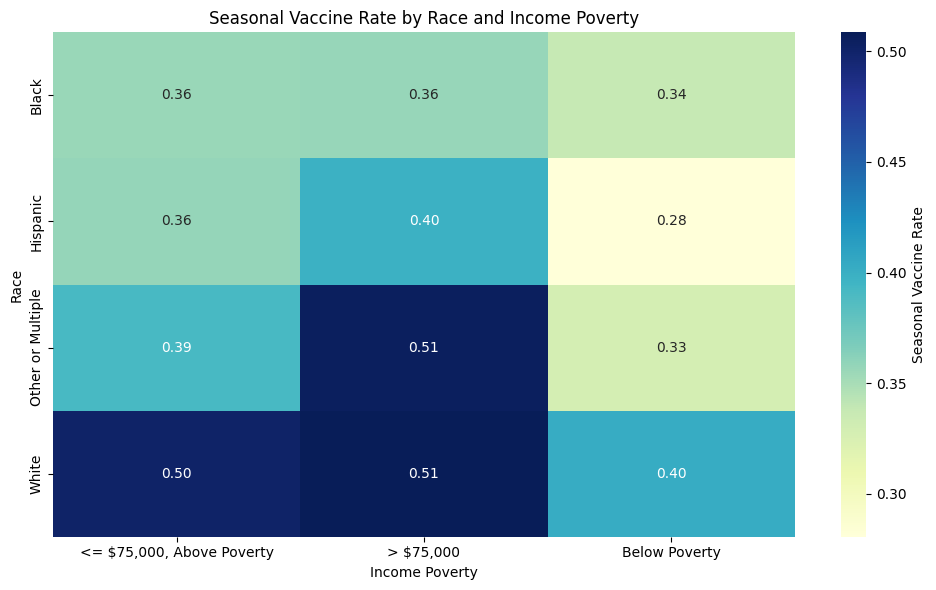

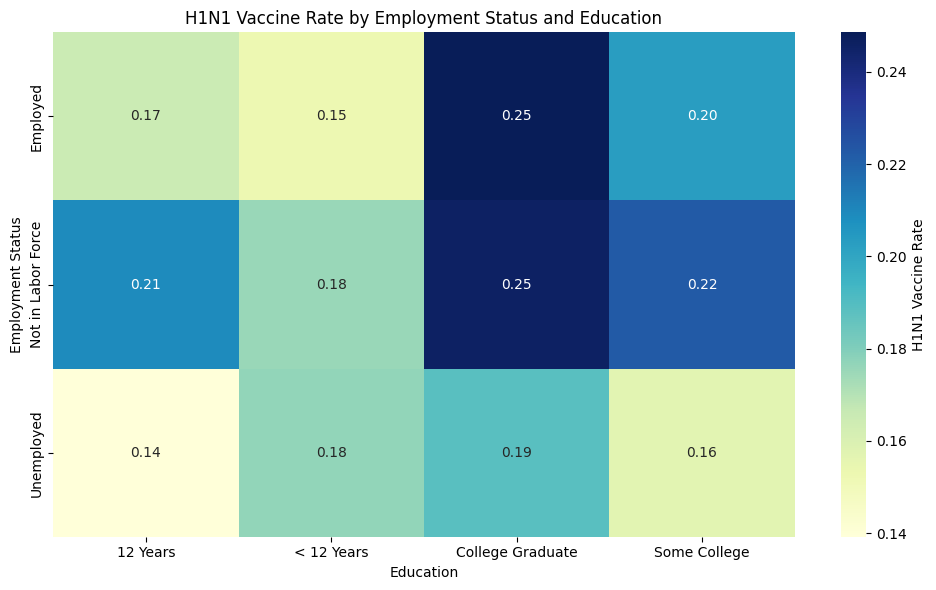

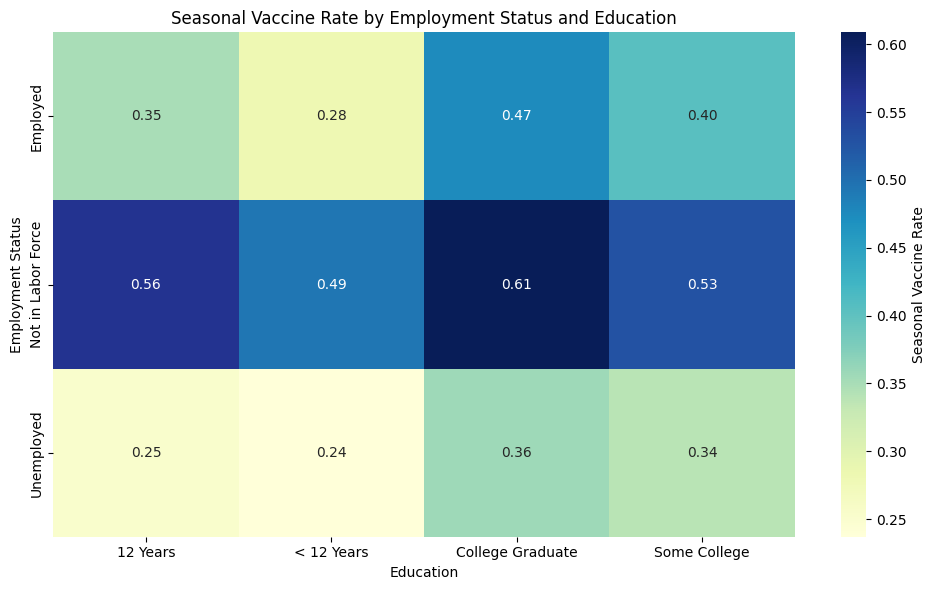

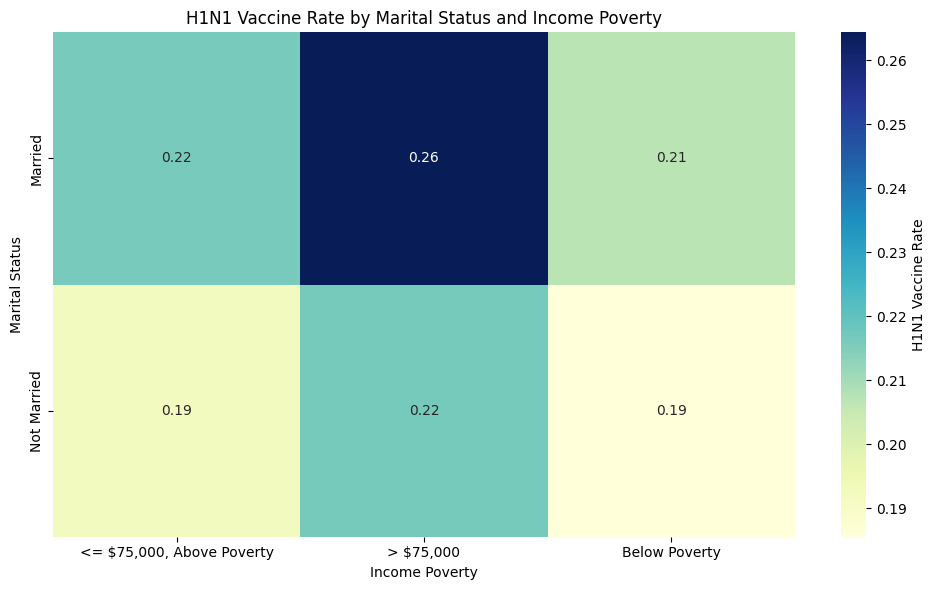

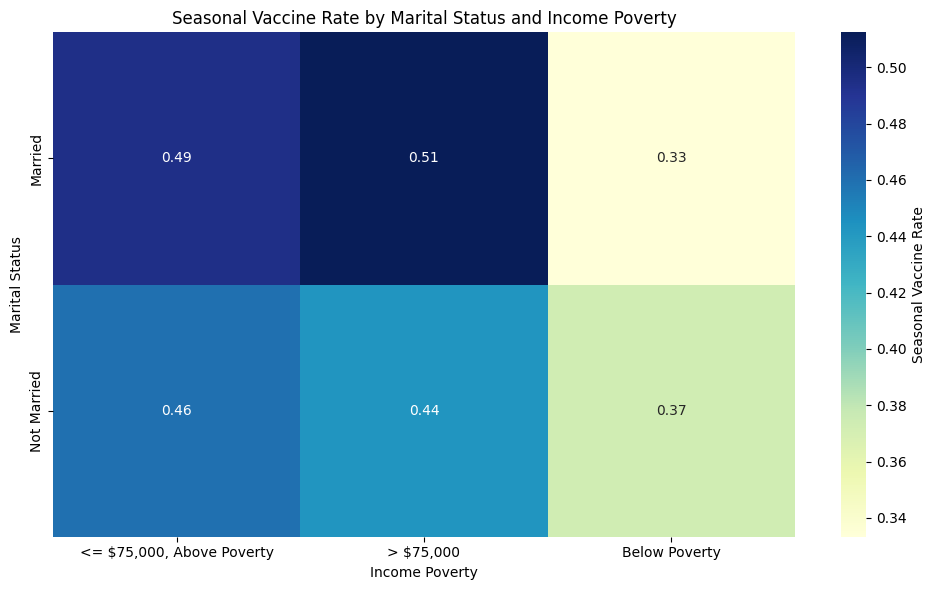

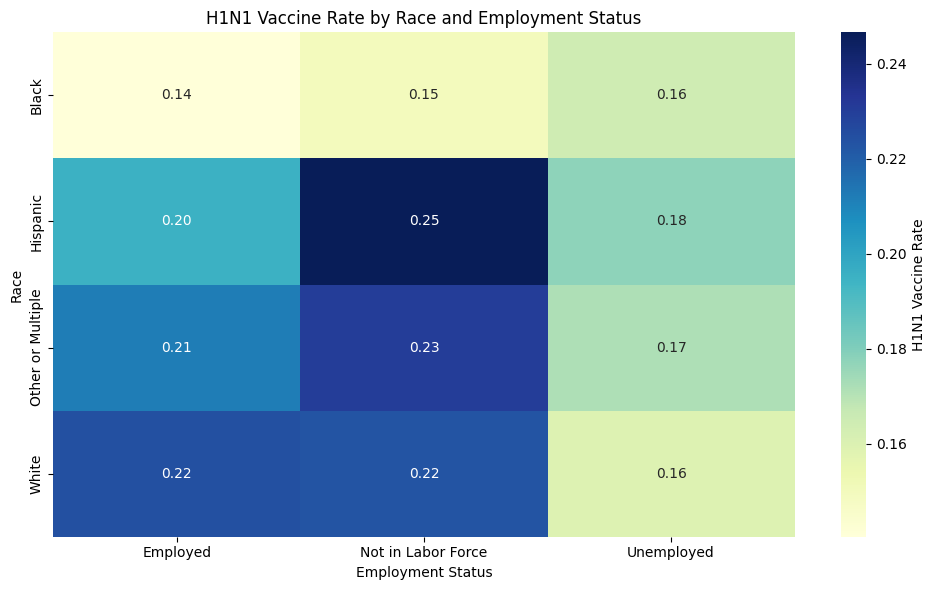

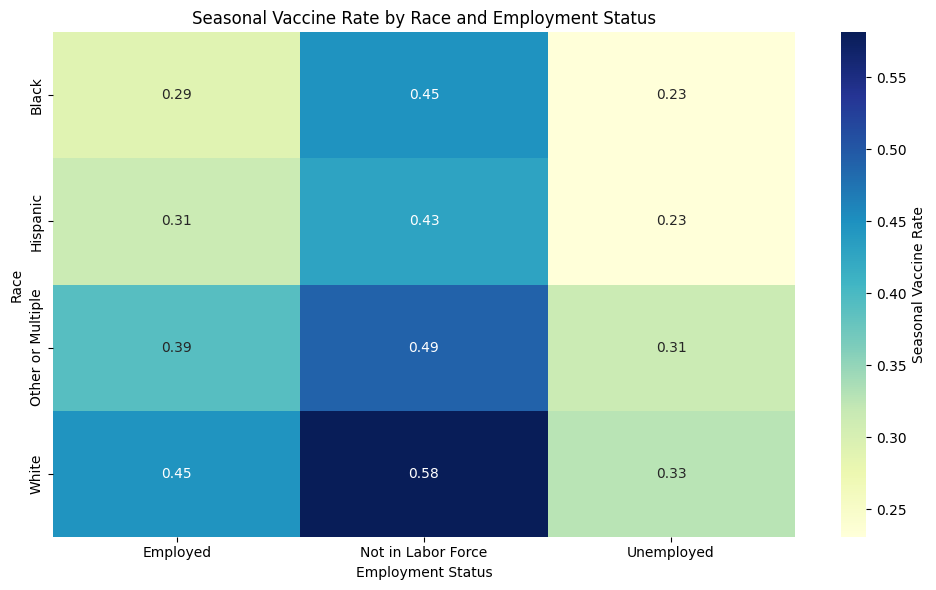

In [ ]:
heatmap_combos = [
    ('age_group', 'employment_status'),
    ('age_group', 'income_poverty'),
    ('sex', 'age_group'),
    ('race', 'income_poverty'),
    ('employment_status', 'education'),
    ('marital_status', 'income_poverty'),
    ('race', 'employment_status'),
]

for idx, col in heatmap_combos:
    plot_heatmap(train_data, idx, col, vaccine_col='h1n1_vaccine')
    plot_heatmap(train_data, idx, col, vaccine_col='seasonal_vaccine')



##### 2- Use appropriate statistical tests to verify observed differences

In [ ]:
#Chi-Square test compares the actual counts in the data to the expected counts(what to expect if the demographic variable didn't matter, how many should be vaccinated in that demographic group) 

#demographic variables
demographic_vars = [
    'age_group',
    'income_poverty',
    'sex',
    'education',
    'marital_status',
    'race',
    'employment_status'
]

# vaccines
vaccine_targets = ['h1n1_vaccine', 'seasonal_vaccine']

In [ ]:
#Chi-Square tests
for demo_var in demographic_vars:
    for vaccine in vaccine_targets:
        contingency = pd.crosstab(train_data[demo_var], train_data[vaccine])
        chi2, p, dof, expected = chi2_contingency(contingency)
        print(f"Chi-Square test: {demo_var} vs {vaccine}")
        print(f"Chi2 = {chi2:.2f}, p-value = {p:.4f}")



Chi-Square test: age_group vs h1n1_vaccine
Chi2 = 69.45, p-value = 0.0000
Chi-Square test: age_group vs seasonal_vaccine
Chi2 = 2175.61, p-value = 0.0000
Chi-Square test: income_poverty vs h1n1_vaccine
Chi2 = 76.29, p-value = 0.0000
Chi-Square test: income_poverty vs seasonal_vaccine
Chi2 = 146.68, p-value = 0.0000
Chi-Square test: sex vs h1n1_vaccine
Chi2 = 11.31, p-value = 0.0008
Chi-Square test: sex vs seasonal_vaccine
Chi2 = 158.40, p-value = 0.0000
Chi-Square test: education vs h1n1_vaccine
Chi2 = 123.04, p-value = 0.0000
Chi-Square test: education vs seasonal_vaccine
Chi2 = 134.84, p-value = 0.0000
Chi-Square test: marital_status vs h1n1_vaccine
Chi2 = 66.10, p-value = 0.0000
Chi-Square test: marital_status vs seasonal_vaccine
Chi2 = 69.29, p-value = 0.0000
Chi-Square test: race vs h1n1_vaccine
Chi2 = 57.01, p-value = 0.0000
Chi-Square test: race vs seasonal_vaccine
Chi2 = 294.73, p-value = 0.0000
Chi-Square test: employment_status vs h1n1_vaccine
Chi2 = 24.23, p-value = 0.0000
C

#### Ticket 1.3.3: Analyze correlations between opinions/behaviors and vaccination decisions

##### 1- Generate correlation matrices and visualize with heatmaps

##### 2- Create charts showing vaccination rates by opinion and behavioral factors

#### Ticket 1.3.4: Investigate geographical patterns in vaccination rates

##### 1- Create maps of vaccination rates by geographic region

##### 2- Compare urban vs. rural vaccination patterns

## Task 1.4: Feature Analysis

#### Ticket 1.4.1: Calculate correlation matrix for all features


##### 1- Compute appropriate correlation coefficients for all variable types

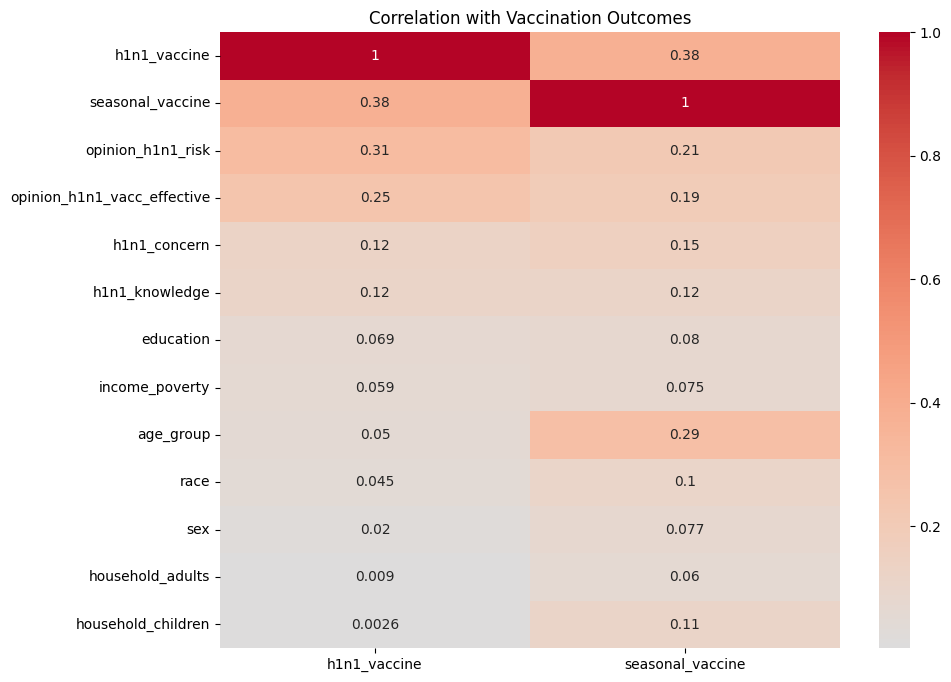

In [ ]:
import matplotlib.pyplot as plt
from dython.nominal import associations

# 2. Define variable types
numerical = ['h1n1_concern', 'h1n1_knowledge', 'opinion_h1n1_vacc_effective',
            'opinion_h1n1_risk', 'household_adults', 'household_children']

categorical = ['age_group', 'education', 'race', 'sex', 'income_poverty']

binary_targets = ['h1n1_vaccine', 'seasonal_vaccine']

# 3. Compute associations using dython (handles mixed data types)
assoc = associations(
    train_data[numerical + categorical + binary_targets],
    nominal_columns=categorical + binary_targets,
    plot=False,
    compute_only=True
)

# 4. Visualize correlations with targets
target_corrs = assoc['corr'][['h1n1_vaccine', 'seasonal_vaccine']].sort_values(
    'h1n1_vaccine', ascending=False)

plt.figure(figsize=(10, 8))
plt.title("Correlation with Vaccination Outcomes")
sns.heatmap(target_corrs, annot=True, cmap='coolwarm', center=0)
plt.show()


In [ ]:
education_order = [
    '< 12 Years', '12 Years', 'Some College', 'College Graduate'
]

train_data['education_ord'] = train_data['education'].map(
    lambda x: education_order.index(x) if x in education_order else -1
)

print(train_data[['education_ord', 'h1n1_vaccine']].corr(method='spearman'))


               education_ord  h1n1_vaccine
education_ord       1.000000      0.068458
h1n1_vaccine        0.068458      1.000000


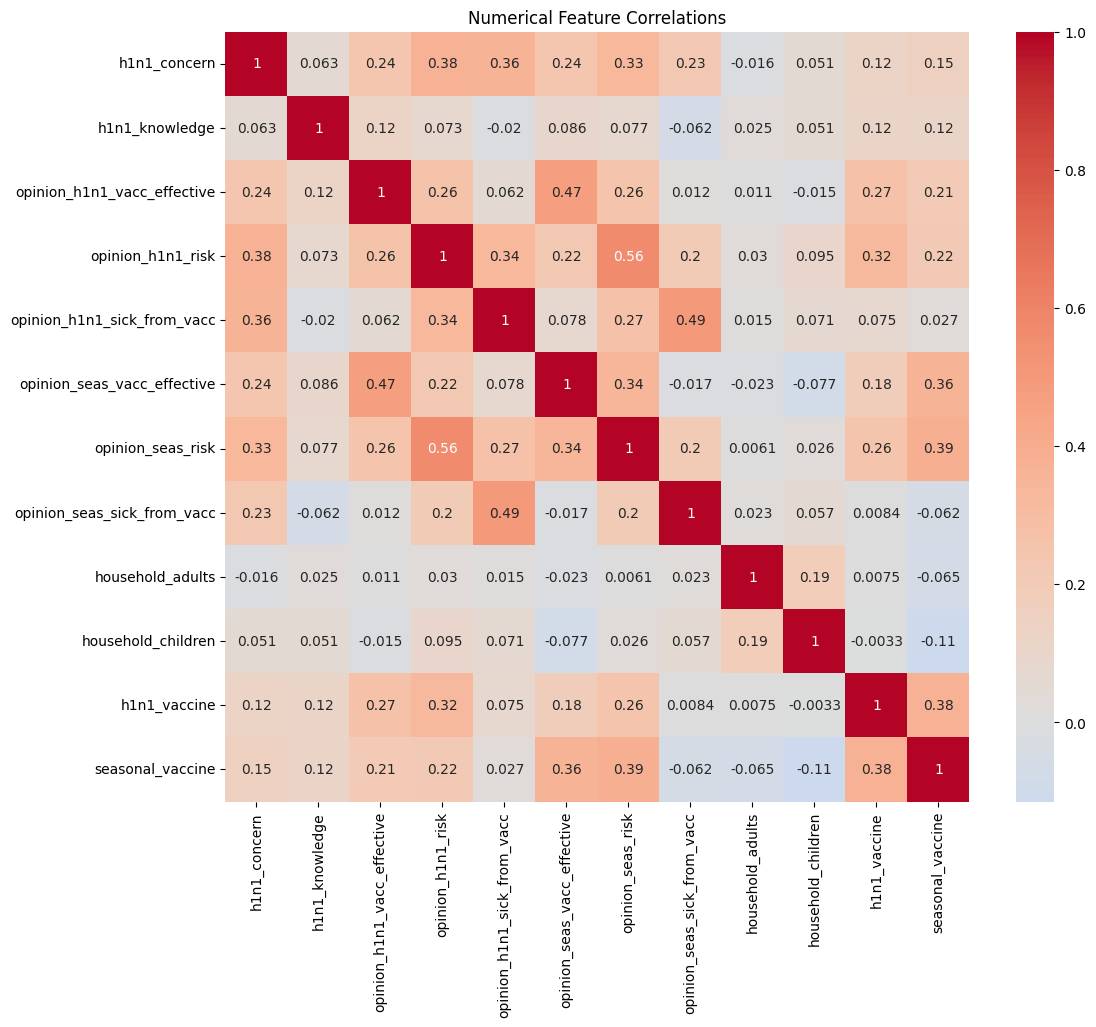

c:\Users\ReDi_NRW_6616\Desktop\Project-A_Data-Circle\myenv\Lib\site-packages\dython\nominal.py:558: FutureWarning: Downcasting object dtype arrays on .fillna, .ffill, .bfill is deprecated and will change in a future version. Call result.infer_objects(copy=False) instead. To opt-in to the future behavior, set `pd.set_option('future.no_silent_downcasting', True)`
  df.fillna(nan_replace_value, inplace=True)


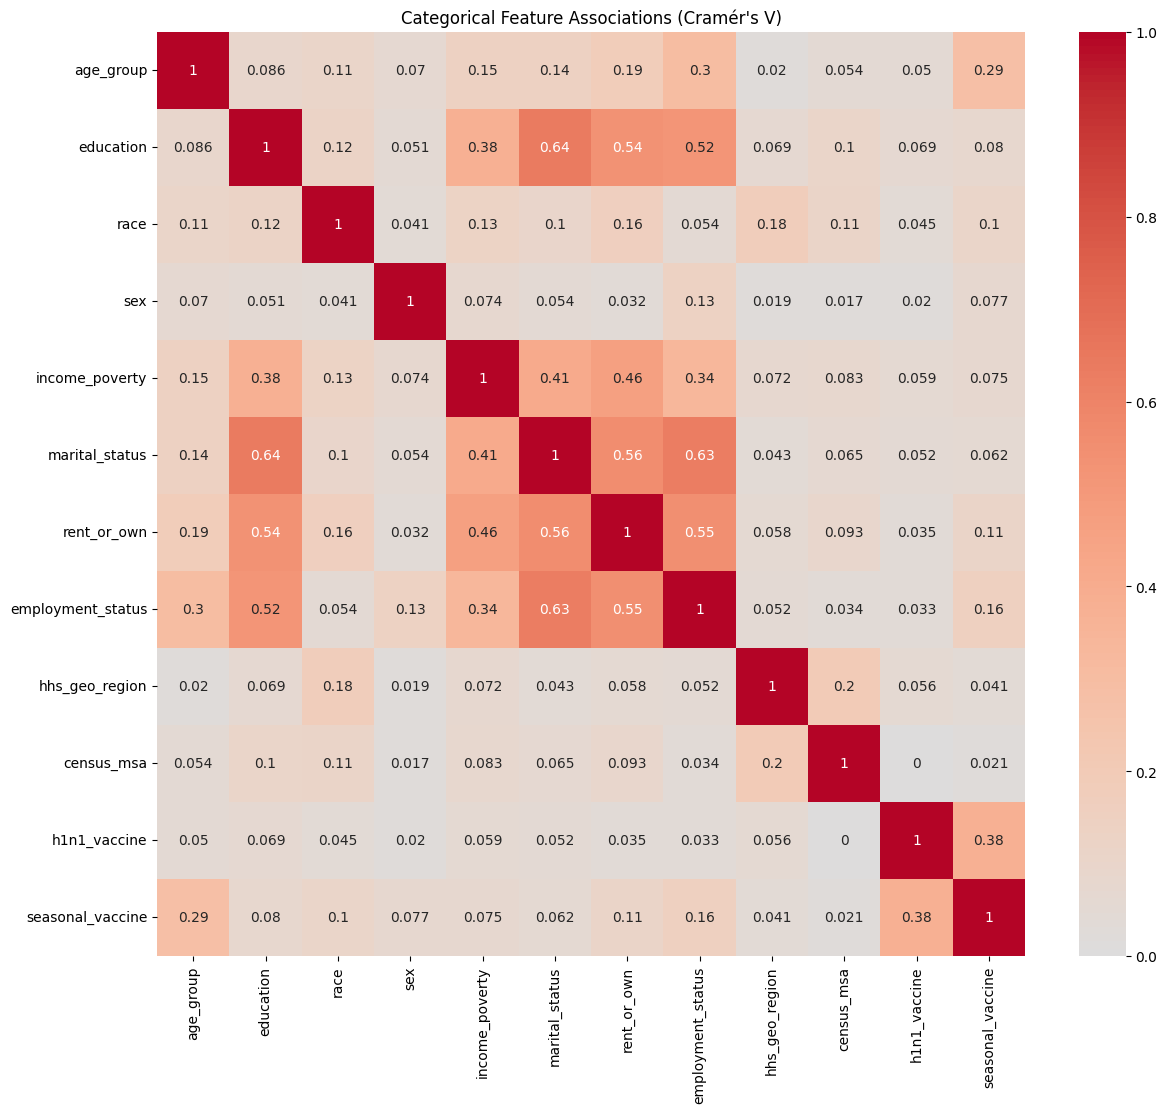

c:\Users\ReDi_NRW_6616\Desktop\Project-A_Data-Circle\myenv\Lib\site-packages\seaborn\matrix.py:202: RuntimeWarning: All-NaN slice encountered
  vmin = np.nanmin(calc_data)
c:\Users\ReDi_NRW_6616\Desktop\Project-A_Data-Circle\myenv\Lib\site-packages\seaborn\matrix.py:207: RuntimeWarning: All-NaN slice encountered
  vmax = np.nanmax(calc_data)


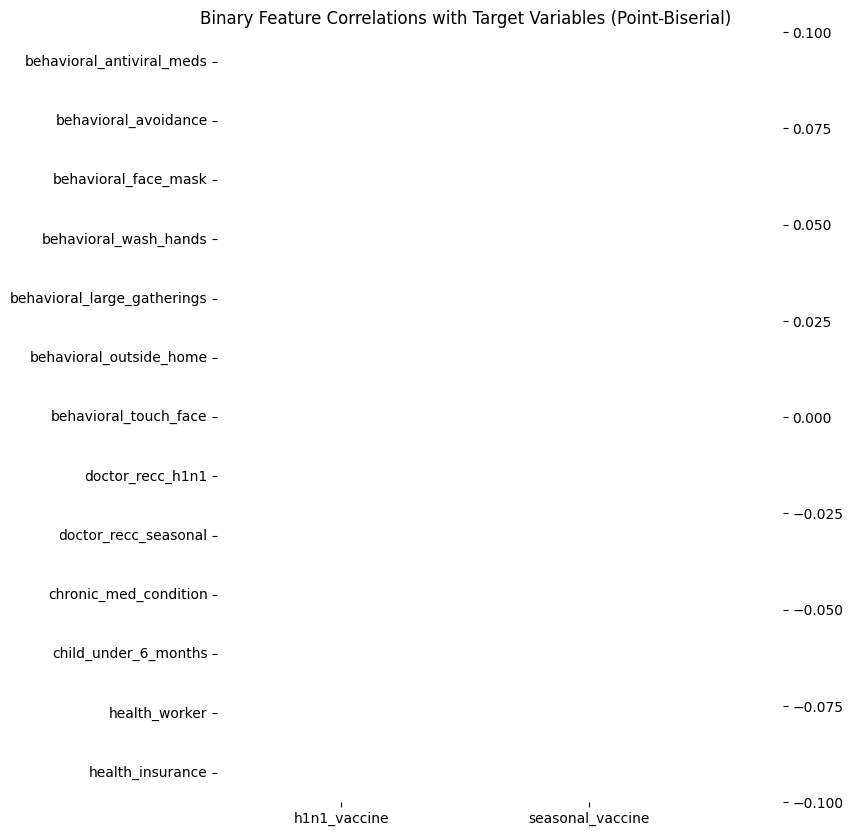

In [ ]:
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
from scipy.stats import pointbiserialr, spearmanr
from dython.nominal import associations

# Define variable types
numerical = [
    'h1n1_concern', 'h1n1_knowledge', 'opinion_h1n1_vacc_effective',
    'opinion_h1n1_risk', 'opinion_h1n1_sick_from_vacc',
    'opinion_seas_vacc_effective', 'opinion_seas_risk',
    'opinion_seas_sick_from_vacc', 'household_adults', 'household_children'
]

categorical = ['age_group', 'education', 'race', 'sex', 'income_poverty',
               'marital_status', 'rent_or_own', 'employment_status',
               'hhs_geo_region', 'census_msa']

binary = [
    'behavioral_antiviral_meds', 'behavioral_avoidance',
    'behavioral_face_mask', 'behavioral_wash_hands',
    'behavioral_large_gatherings', 'behavioral_outside_home',
    'behavioral_touch_face', 'doctor_recc_h1n1', 'doctor_recc_seasonal',
    'chronic_med_condition', 'child_under_6_months', 'health_worker',
    'health_insurance'
]

target = ['h1n1_vaccine', 'seasonal_vaccine']

# 1. Numerical Features Correlation
num_corr = train_data[numerical + target].corr(method='pearson')
plt.figure(figsize=(12, 10))
sns.heatmap(num_corr, annot=True, cmap='coolwarm', center=0)
plt.title("Numerical Feature Correlations")
plt.show()

# 2. Categorical Features Association (Cramér's V)
cat_data = train_data[categorical + target].copy() # Create a copy to avoid modifying the original DataFrame

# Convert target variables to 'object' dtype for categorical association
cat_data['h1n1_vaccine'] = cat_data['h1n1_vaccine'].astype('object')
cat_data['seasonal_vaccine'] = cat_data['seasonal_vaccine'].astype('object')

# Create a list of nominal columns that includes target variables
nominal_columns = categorical + target

cat_assoc = associations(cat_data, nominal_columns=nominal_columns, plot=False, compute_only=True)
plt.figure(figsize=(14, 12))
sns.heatmap(cat_assoc['corr'], annot=True, cmap='coolwarm', center=0)
plt.title("Categorical Feature Associations (Cramér's V)")
plt.show()

# 3. Binary Features (Point-Biserial with Target)
binary_target_corrs = {}
for bin_col in binary:
    h1n1_corr, _ = pointbiserialr(train_data[bin_col], train_data['h1n1_vaccine'])
    seas_corr, _ = pointbiserialr(train_data[bin_col], train_data['seasonal_vaccine'])
    binary_target_corrs[bin_col] = {'h1n1_vaccine': h1n1_corr, 'seasonal_vaccine': seas_corr}

binary_target_train_data = pd.DataFrame(binary_target_corrs).T
plt.figure(figsize=(8, 10))
sns.heatmap(binary_target_train_data, annot=True, cmap='coolwarm', center=0)
plt.title("Binary Feature Correlations with Target Variables (Point-Biserial)")
plt.show()


##### 2- Generate correlation heatmaps with hierarchical clustering

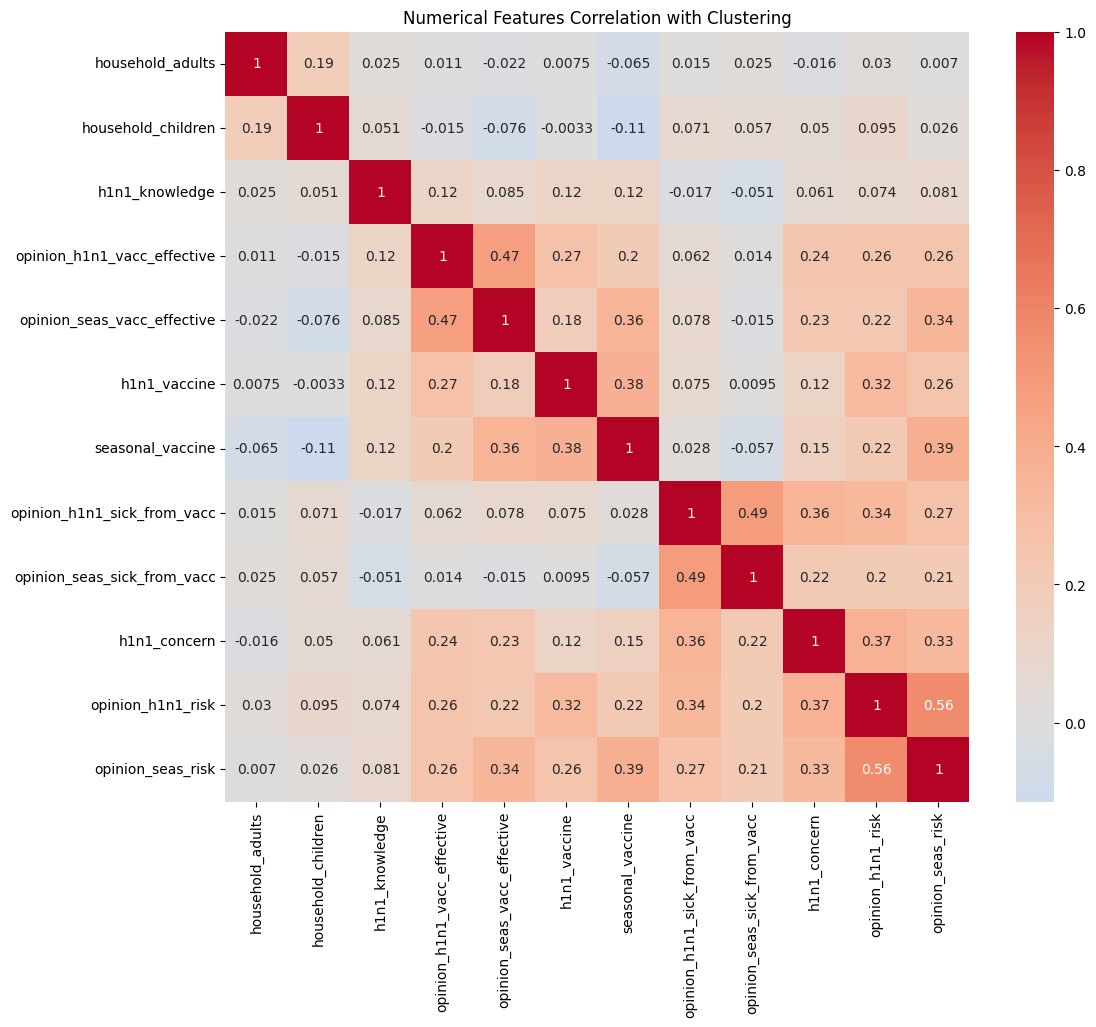

KeyError: "['race', 'employment_status', 'hhs_geo_region', 'census_msa'] not in index"

In [35]:
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
from scipy.stats import pointbiserialr, spearmanr
from dython.nominal import associations
from scipy.cluster.hierarchy import linkage, leaves_list

# Define variable types
numerical = [
    'h1n1_concern', 'h1n1_knowledge', 'opinion_h1n1_vacc_effective',
    'opinion_h1n1_risk', 'opinion_h1n1_sick_from_vacc',
    'opinion_seas_vacc_effective', 'opinion_seas_risk',
    'opinion_seas_sick_from_vacc', 'household_adults', 'household_children'
]

categorical = ['age_group', 'education', 'race', 'sex', 'income_poverty',
               'marital_status', 'rent_or_own', 'employment_status',
               'hhs_geo_region', 'census_msa']

binary = [
    'behavioral_antiviral_meds', 'behavioral_avoidance',
    'behavioral_face_mask', 'behavioral_wash_hands',
    'behavioral_large_gatherings', 'behavioral_outside_home',
    'behavioral_touch_face', 'doctor_recc_h1n1', 'doctor_recc_seasonal',
    'chronic_med_condition', 'child_under_6_months', 'health_worker',
    'health_insurance'
]

target = ['h1n1_vaccine', 'seasonal_vaccine']

# Function for hierarchical clustering and heatmap
def clustered_heatmap(train_data, title):
    corr = train_data.corr()
    linkage_matrix = linkage(corr)
    idx = leaves_list(linkage_matrix)
    corr_reordered = corr.iloc[idx, idx]

    plt.figure(figsize=(12, 10))
    sns.heatmap(corr_reordered, annot=True, cmap='coolwarm', center=0)
    plt.title(title)
    plt.show()

# 1. Numerical Features
clustered_heatmap(train_data[numerical + target], "Numerical Features Correlation with Clustering")

# 2. Categorical Features (using dython's associations)
cat_data = train_data[categorical + target].copy()
cat_data['h1n1_vaccine'] = cat_data['h1n1_vaccine'].astype('object')
cat_data['seasonal_vaccine'] = cat_data['seasonal_vaccine'].astype('object')
nominal_columns = categorical + target

cat_assoc = associations(cat_data, nominal_columns=nominal_columns, plot=False, compute_only=True)
cat_corr = cat_assoc['corr']

# Perform hierarchical clustering
linkage_matrix = linkage(cat_corr, method='ward')  # 'ward' minimizes variance
idx = leaves_list(linkage_matrix)  # get the order of the leaves
cat_corr_reordered = cat_corr.iloc[idx, idx]

plt.figure(figsize=(14, 12))
sns.heatmap(cat_corr_reordered, annot=True, cmap='coolwarm', center=0)
plt.title("Categorical Feature Associations with Clustering")
plt.show()

# 3. Binary Features (Point-Biserial with Target)
binary_target_corrs = {}
for bin_col in binary:
    h1n1_corr, _ = pointbiserialr(train_data[bin_col], train_data['h1n1_vaccine'])
    seas_corr, _ = pointbiserialr(train_data[bin_col], train_data['seasonal_vaccine'])
    binary_target_corrs[bin_col] = {'h1n1_vaccine': h1n1_corr, 'seasonal_vaccine': seas_corr}

binary_target_train_data = pd.DataFrame(binary_target_corrs).T

# Perform hierarchical clustering
linkage_matrix = linkage(binary_target_train_data)
idx = leaves_list(linkage_matrix)
binary_target_train_data_reordered = binary_target_train_data.iloc[idx, :]

plt.figure(figsize=(8, 10))
sns.heatmap(binary_target_train_data_reordered, annot=True, cmap='coolwarm', center=0)
plt.title("Binary Feature Correlations with Target Variables (Point-Biserial) and Clustering")
plt.show()


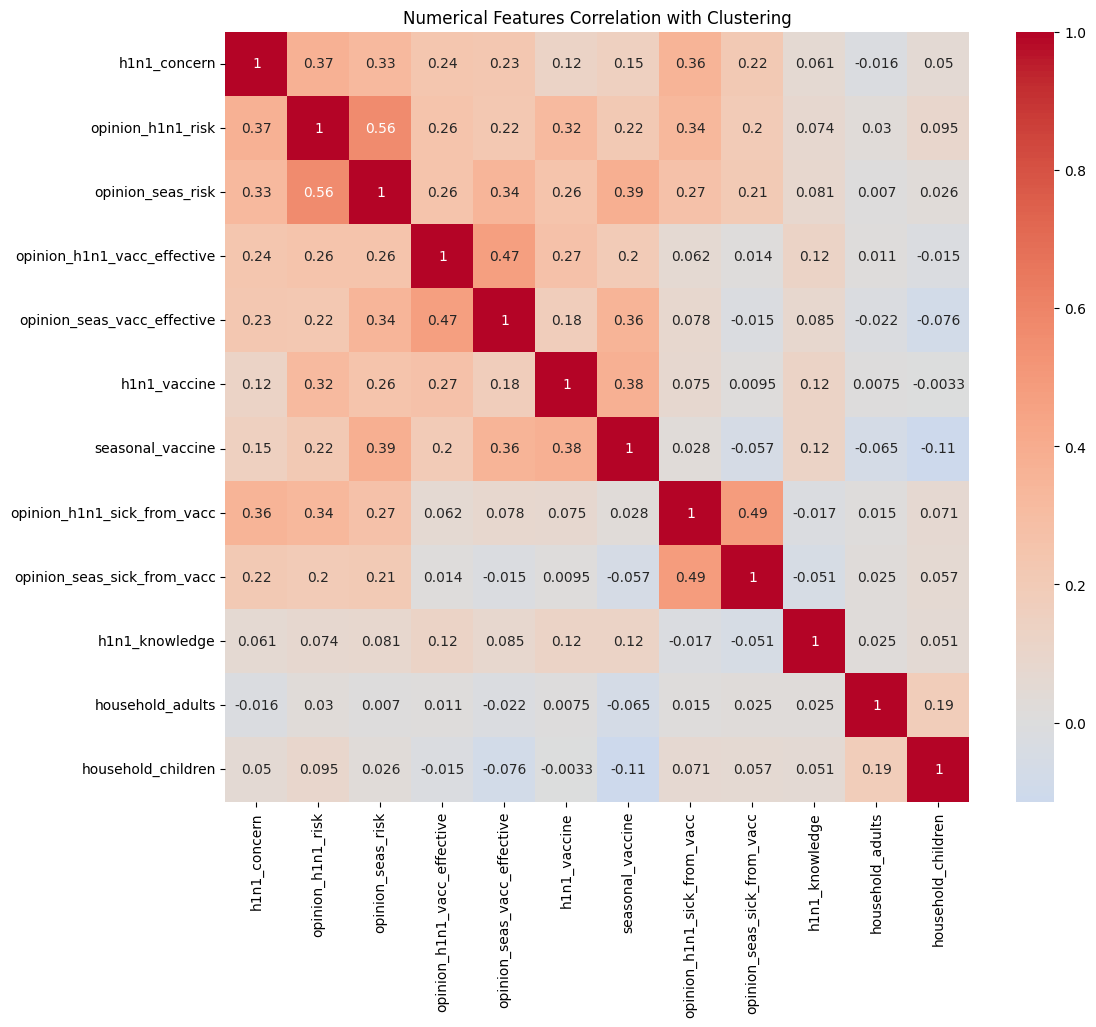

KeyError: "['race', 'employment_status', 'hhs_geo_region', 'census_msa'] not in index"

In [36]:
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
from scipy.stats import pointbiserialr, spearmanr
from dython.nominal import associations
from scipy.cluster.hierarchy import linkage, leaves_list
import numpy as np

# Assuming train_data is your DataFrame
# train_data = pd.read_csv('your_data.csv') # if you still need to read

# Define variable types
numerical = [
    'h1n1_concern', 'h1n1_knowledge', 'opinion_h1n1_vacc_effective',
    'opinion_h1n1_risk', 'opinion_h1n1_sick_from_vacc',
    'opinion_seas_vacc_effective', 'opinion_seas_risk',
    'opinion_seas_sick_from_vacc', 'household_adults', 'household_children'
]

categorical = ['age_group', 'education', 'race', 'sex', 'income_poverty',
               'marital_status', 'rent_or_own', 'employment_status',
               'hhs_geo_region', 'census_msa']

binary = [
    'behavioral_antiviral_meds', 'behavioral_avoidance',
    'behavioral_face_mask', 'behavioral_wash_hands',
    'behavioral_large_gatherings', 'behavioral_outside_home',
    'behavioral_touch_face', 'doctor_recc_h1n1', 'doctor_recc_seasonal',
    'chronic_med_condition', 'child_under_6_months', 'health_worker',
    'health_insurance'
]

target = ['h1n1_vaccine', 'seasonal_vaccine']

# Clean data by removing all NA
train_data = train_data.dropna()

# Function for hierarchical clustering and heatmap
def clustered_heatmap(df, title):
    # Compute the correlation matrix
    corr = df.corr()

    # Remove rows and columns containing NaN values
    corr = corr.dropna(axis=0, how='any')
    corr = corr.dropna(axis=1, how='any')

    # Check if there are enough columns left to perform hierarchical clustering
    if corr.shape[1] <= 1:
        print(f"Not enough columns left for {title} after removing NaN values. Skipping clustering.")
        return

    # Perform hierarchical clustering
    linkage_matrix = linkage(corr, method='ward')
    idx = leaves_list(linkage_matrix)
    corr_reordered = corr.iloc[idx, idx]

    plt.figure(figsize=(12, 10))
    sns.heatmap(corr_reordered, annot=True, cmap='coolwarm', center=0)
    plt.title(title)
    plt.show()

# 1. Numerical Features
clustered_heatmap(train_data[numerical + target], "Numerical Features Correlation with Clustering")

# 2. Categorical Features (using dython's associations)
cat_data = train_data[categorical + target].copy()
cat_data['h1n1_vaccine'] = cat_data['h1n1_vaccine'].astype('object')
cat_data['seasonal_vaccine'] = cat_data['seasonal_vaccine'].astype('object')
nominal_columns = categorical + target

cat_assoc = associations(cat_data, nominal_columns=nominal_columns, plot=False, compute_only=True)
cat_corr = cat_assoc['corr']

cat_corr = cat_corr.dropna(axis=0, how='any')
cat_corr = cat_corr.dropna(axis=1, how='any')

# Perform hierarchical clustering
if cat_corr.shape[1] > 1:  # Ensure at least two columns remain
    linkage_matrix = linkage(cat_corr, method='ward')
    idx = leaves_list(linkage_matrix)
    cat_corr_reordered = cat_corr.iloc[idx, idx]

    plt.figure(figsize=(14, 12))
    sns.heatmap(cat_corr_reordered, annot=True, cmap='coolwarm', center=0)
    plt.title("Categorical Feature Associations with Clustering")
    plt.show()
else:
    print("Not enough columns left for Categorical Feature Associations after removing NaN values.")

# 3. Binary Features (Point-Biserial with Target)
binary_target_corrs = {}
for bin_col in binary:
    h1n1_corr, _ = pointbiserialr(train_data[bin_col], train_data['h1n1_vaccine'])
    seas_corr, _ = pointbiserialr(train_data[bin_col], train_data['seasonal_vaccine'])
    binary_target_corrs[bin_col] = {'h1n1_vaccine': h1n1_corr, 'seasonal_vaccine': seas_corr}

binary_target_df = pd.DataFrame(binary_target_corrs).T

binary_target_df = binary_target_df.dropna(axis=0, how='any')
binary_target_df = binary_target_df.dropna(axis=1, how='any')

if binary_target_df.shape[0] > 1:
    # Perform hierarchical clustering
    linkage_matrix = linkage(binary_target_df, method='ward')
    idx = leaves_list(linkage_matrix)
    binary_target_df_reordered = binary_target_df.iloc[idx, :]

    plt.figure(figsize=(8, 10))
    sns.heatmap(binary_target_df_reordered, annot=True, cmap='coolwarm', center=0)
    plt.title("Binary Feature Correlations with Target Variables (Point-Biserial) and Clustering")
    plt.show()
else:
    print("Not enough rows left for Binary Feature Correlations after removing NaN values.")


#### Ticket 1.4.2: Identify potentially redundant features

##### 1- Detect highly correlated feature pairs

##### 2- Recommend which features could be combined or removed

#### Ticket 1.4.3: Conduct preliminary feature importance analysis

##### 1- Use simple models to rank features by importance

##### 2- Compare feature importance between H1N1 and seasonal flu targets

#### Ticket 1.4.4: Document insights about which factors appear most influential

##### 1- Summarize key findings from correlation and importance analyses

##### 2- Identify unexpected or counterintuitive relationships

## Task.1.5: EDA Report Compilation

#### Ticket 1.5.1: Summarize key findings and insights


##### 1- Create an executive summary of important discoveries

##### 2- Connect insights to project goals and modeling approaches

#### Ticket 1.5.2: Compile all visualizations with clear explanations

##### 1- Create a visualization appendix with all exploratory plots

##### 2- Ensure all visualizations have proper titles and explanations

#### Ticket 1.5.3: Document preprocessing steps and rationale

##### 1- Create a methodology section describing cleaning approaches

##### 2- Address potential limitations or biases introduced during preprocessing

#### Ticket 1.5.4: Create presentation for Sprint 1 review

##### 1- Design 5-7 slides highlighting key finding

##### 2- Prepare speaking notes and anticipate questions